In [6]:
# Load packages
import sys
import numpy as np
import pandas as pd
import scipy
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 #high res figures
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
import xgboost as xgb
import shap
import pickle
from sklearn.metrics import roc_auc_score

# Review of modeling results

business partners may not understand the
derivation of the ROC AUC measure; however, this is an important concept since it's
the main performance metric we used to assess models. You may need to explain
that it's a metric that can vary between 0.5 and 1 and give intuitive explanations
for these limits: 0.5 is no better than a coin flip and 1 is perfection, which is
essentially unattainable.

Our results are somewhere in between, getting close to 0.78 with the best model we
developed. While the ROC AUC of a given model may not necessarily be meaningful
by itself, the Figure below shows that we've tried several methods and have achieved
improved performance above our initial attempts. In the end, for a business
application like the case study, abstract model performance metrics like the ROC AUC
should be accompanied by a financial analysis if possible. 


Note: on Interpreting the ROC AUC

An interesting interpretation of the ROC AUC score is the probability that
for two samples, one with a positive outcome and one with a negative
outcome, the positive sample will have a higher predicted probability than
the negative sample. In other words, for all possible pairs of positive and
negative samples in the dataset being assessed, the proportion of pairs
where the positive sample has a higher model prediction than the negative
sample is equivalent to the ROC AUC.

| Model | Location | Tuned hyperparameters | Validation ROC AUC |
| :--- | :--- | :--- | :--- |
| Logistic regression with L1 regularization | Project-4| Regularization parameter C | 0.719 |
| Logistic regression with interaction features | Project-4| Regularization parameter C | 0.739 |
| Decision tree | Project-5 | Maximum depth | 0.746 |
| Random forest | Project-5 | Maximum depth and number of trees | 0.776 |
| XGBoost | Project-6 | Maximum leaves | 0.779 |

we can see that for the case study, our efforts in creating more
complex models, either by engineering new features to add to a simple logistic
regression or by creating an ensemble of decision trees, yielded better model
performance. In particular, the random forest and XGBoost models perform similarly,
although these validation scores are technically not directly comparable since in the
case of random forest we excluded missing values and used 4-fold cross-validation,
while for XGBoost the missing values were included and there was just one validation
set that was used for early stopping. However, the Figure above provides an indication that
either XGBoost or random forest would probably be the best choice. We'll move
forward here with the XGBoost model.

p.s.Random Forest（随机森林）通常不能直接处理 Missing Value。在大多数传统的随机森林实现（如 Python 中最常用的 scikit-learn 库）中，模型不支持输入包含缺失值（NaN）的数据。XGBoost 采用了一种叫做**稀疏感知分裂（Sparsity-aware Split Finding）**的策略：
默认路径（Default Direction）：对于每个特征，XGBoost 会自动学习出一个“默认方向”。如果某个样本在这个特征上缺失，它会被直接派发到这个默认的分支中。
自动学习：模型会通过实验发现，把缺失值分到左边还是右边能获得更好的损失函数收益。这使得它不需要手动填补就能处理缺失数据。

# xgboost也可以用4 folds，但是因为要有early stop，最后fit的时候要传入eval_set
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# 1. 定义模型：直接在初始化时放入“监控”规则
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, 
    learning_rate=0.1,
    max_depth=0,
    grow_policy='lossguide',
    tree_method='hist',
    early_stopping_rounds=30, # 新版可以直接写在这里
    eval_metric='auc'          # 指定监控指标
)

# 2. 定义参数网格（和你做 RF 一模一样）
param_grid = {
    'max_leaves': [15, 31, 63],
    'subsample': [0.8, 1.0]
}

# 3. 像 RF 一样进行 Grid Search
cv_xgb = GridSearchCV(
    xgb_model, 
    param_grid=param_grid, 
    scoring='roc_auc', 
    cv=4, 
    n_jobs=-1
)

# 4. 一键开启（注意：fit 时传入验证集即可激活早停）
cv_xgb.fit(X_train_all, y_train_all, eval_set=[(X_test_all, y_test_all)], verbose=False)

# Further Model Development Thoughts
1. Feature Engineering

we could engineer a new feature: the ratio of past monthly billed
amounts to the credit limit, assuming the billed amount is the account's balance. This
measure of credit utilization may be a stronger feature, and result in better model
performance when calculated in this way, than having the credit limit and monthly
billed amounts available to the model separately.

The inspiration for new features may come from domain knowledge: it can be very
helpful to have a conversation with your business partner about what they think
good features might be, especially if they have more domain knowledge than you for
the application you're on. Examining the interactions of existing features can also be
a way to hypothesize new features.

2. Ensembling Multiple Models

In choosing the final model to deliver for the case study project, it would probably be
fine to deliver either random forest or XGBoost. Another commonly used approach
in machine learning is to ensemble together multiple models. This means combining
the predictions of different models, similar to how random forest and XGBoost
combine many decision trees. But in this case, the way to combine model predictions
is up to the data scientist. A simple way to create an ensemble of models is to take
the average of their predictions.

Ensembling is often done when there are multiple models, perhaps different kinds
of models or models trained with different features that all have good performance.
In our case, it may be that using the average prediction from the random forest and
XGBoost would have better performance than either model on its own. To explore
this, we could compare performance on a validation set, for example, the one used
for early stopping in XGBoost.

3. Different Modeling Techniques

Depending on how much time you have for a project and your expertise in different
modeling techniques, you will want to try as many methods as possible. More
advanced methods, such as neural networks for classification, may yield improved
performance on this problem. We encourage you to continue your studies and
learn how to use these models. However, for tabular data such as what we have for
the case study, XGBoost is a good de facto choice and will likely provide excellent
performance, if not the best performance of all methods.

4. Balancing Classes
   
Note that we did not address the class imbalance in the response variable. You are
encouraged to try fitting models with the class_weight='balanced' option in
scikit-learn or using the scale_pos_weight hyperparameter in XGBoost, to see
the effect.

# Model Performance on the Test Set

We already have some idea of the out-of-sample performance of the XGBoost model,
from the validation set. However, the validation set was used in model fitting, via
early stopping. The most rigorous estimate of expected future performance we can
make should be created with data that was not used at all for model fitting. This was
the reason for reserving a test dataset from the model building process.

You may notice that we did examine the test set to some extent already, for example,
in the first chapter when assessing data quality and doing data cleaning. The gold
standard for predictive modeling is to set aside a test set at the very beginning of a
project and not examine it at all until the model is finished. This is the easiest way to
make sure that none of the knowledge from the test set has "leaked" into the training
set during model development. When this happens, it opens up the possibility that
the test set is no longer a realistic representation of future, unknown data. However,
it is sometimes convenient to explore and clean all of the data together, as we've
done. If the test data has the same quality issues as the rest of the data, then there
would be no leakage. It is most important to make sure you're not looking at the
test set when you decide which features to use, fit various models, and compare
their performance.

In [3]:
with open('xgb_model_w_data.pkl', 'rb') as f:
    features_response, X_train_all, y_train_all, X_test_all,\
    y_test_all, xgb_model_4 = pickle.load(f)

In [4]:
test_set_pred_proba = xgb_model_4.predict_proba(X_test_all)[:,1]

In [7]:
test_auc = roc_auc_score(y_test_all, test_set_pred_proba)
test_auc

np.float64(0.771827890629116)

The ROC AUC of 0.774 on the test set is a bit lower than the 0.779 we saw on the
validation set for the XGBoost model; however, it is not very different. Since the
model fitting process optimized the model for performance on the validation set,
it's not totally surprising to see somewhat lower performance on new data. Overall,
the testing performance is in line with expectations and we can consider this model
successfully tested in terms of the ROC AUC metric.

While we won't do this here, a final step before delivering a trained model might be
to fit it on all of the available data, including the unseen test set. This could be done
by concatenating the training and testing data features (X_train_all, X_test_
all) and labels (y_train_all, y_test_all), and using them to fit a new model,
perhaps by defining a new validation set for early stopping or using the current test
set for that purpose. This approach is motivated by the idea that machine learning
models generally perform better when trained on more data. The downside is that
since there would be no unseen test set in these circumstances, the final model could
be considered to be untested.

For the purposes of the case study, we'll assume that we wouldn't realize any
benefit from refitting the model using the test set(In reality, we need to test by learning curve). So, our main concerns now are
presenting the model to the client, helping them design a strategy to use it to meet
their business goals, and providing guidance on how the model's performance can be
monitored as time goes on.

p.s. the concept behind a learning curve
is to train a model on successively increasing amounts of data and calculating the
validation score on the same validation set. For example, if you had 10,000 training
samples, you might set aside 500 as a validation set and then train a model on the
first 1,000 samples, then the first 2,000 samples, and so on, up to all 9,500 samples
that aren't in the validation set. If training on more data consistently increases the
validation score even up to the point of using all available data, this is a sign that
training on more data than you have in the training set would be beneficial. However,
if model performance starts to level off at some point and it doesn't seem like
additional data would create a more performant model, you may not need to do this.
Learning curves can provide guidance on which approach to take with the test set, as
well as whether more data is needed in a project generally

# Distribution of Predicted Probability and Decile Chart

Text(0, 0.5, 'Number of samples')

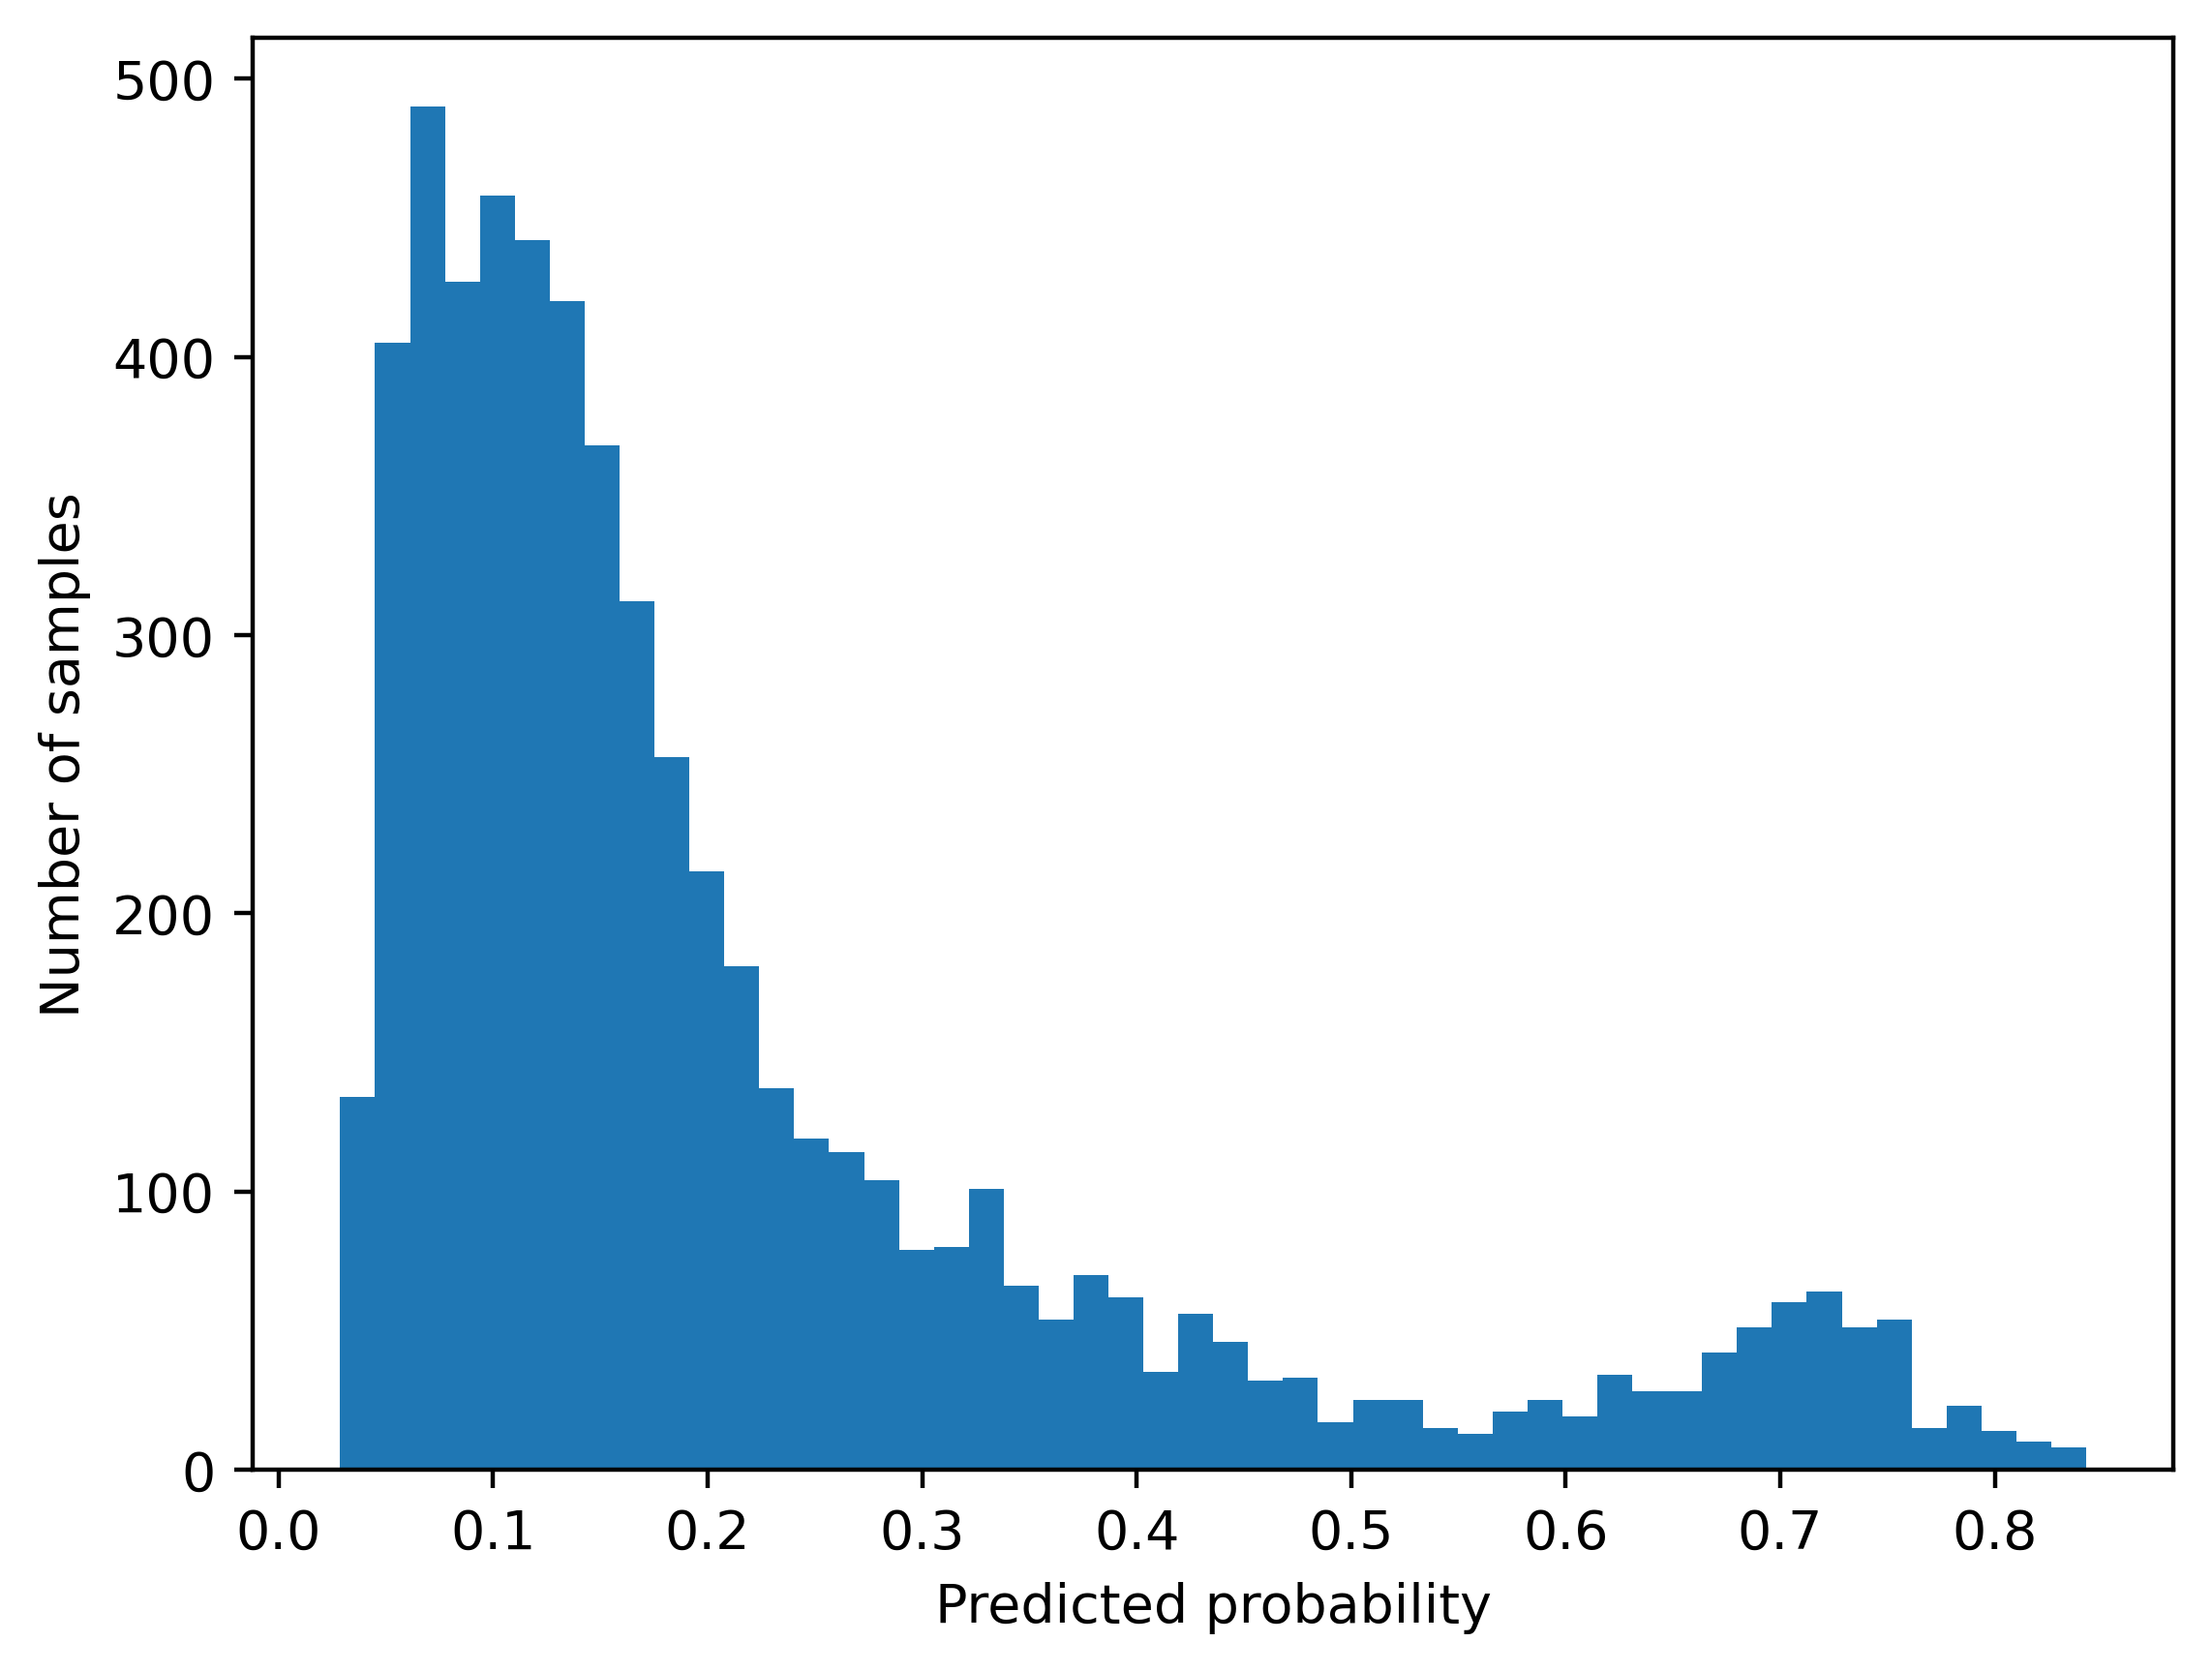

In [8]:
mpl.rcParams['figure.dpi'] = 400
plt.hist(test_set_pred_proba, bins=50)
plt.xlabel('Predicted probability')
plt.ylabel('Number of samples')

The histogram of predicted probabilities for the test set shows that most predictions
are clustered in the range [0, 0.2]. In other words, most borrowers have between
a 0 and 20% chance of default, according to the model. However, there appears to be
a small cluster of borrowers with a higher risk, centered near 0.7

In [9]:
deciles, decile_bin_edges = pd.qcut(x=test_set_pred_proba,q=10,retbins=True)

In [10]:
decile_bin_edges

array([0.02866817, 0.06296656, 0.08341031, 0.10531277, 0.1270338 ,
       0.15042238, 0.18233756, 0.23004555, 0.32266536, 0.51780742,
       0.84259713])

In [11]:
test_set_df = pd.DataFrame({'Predicted probability':test_set_pred_proba,\
 'Prediction decile':deciles,\
 'Outcome':y_test_all})
test_set_df.head()

,Predicted probability,Prediction decile,Outcome
0,0.688628,"(0.518, 0.843]",0
1,0.634731,"(0.518, 0.843]",0
2,0.053137,"(0.0277, 0.063]",0
3,0.842597,"(0.518, 0.843]",1
4,0.325197,"(0.323, 0.518]",0


In [12]:
test_set_gr = test_set_df.groupby('Prediction decile')
gr_df = test_set_gr.agg({'Outcome':['count', 'mean']})
gr_df

/var/folders/dj/nbjnfkrd4kqdr9tqs5m_hrsr0000gn/T/ipykernel_78803/3636182326.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_set_gr = test_set_df.groupby('Prediction decile')


Outcome          
                    count      mean
Prediction decile                  
(0.0277, 0.063]       594  0.050505
(0.063, 0.0834]       594  0.063973
(0.0834, 0.105]       594  0.102694
(0.105, 0.127]        593  0.094435
(0.127, 0.15]         594  0.158249
(0.15, 0.182]         594  0.149832
(0.182, 0.23]         593  0.202361
(0.23, 0.323]         594  0.281145
(0.323, 0.518]        594  0.398990
(0.518, 0.843]        594  0.661616

In [13]:
gr_df.columns

MultiIndex([('Outcome', 'count'),
            ('Outcome',  'mean')],
           )

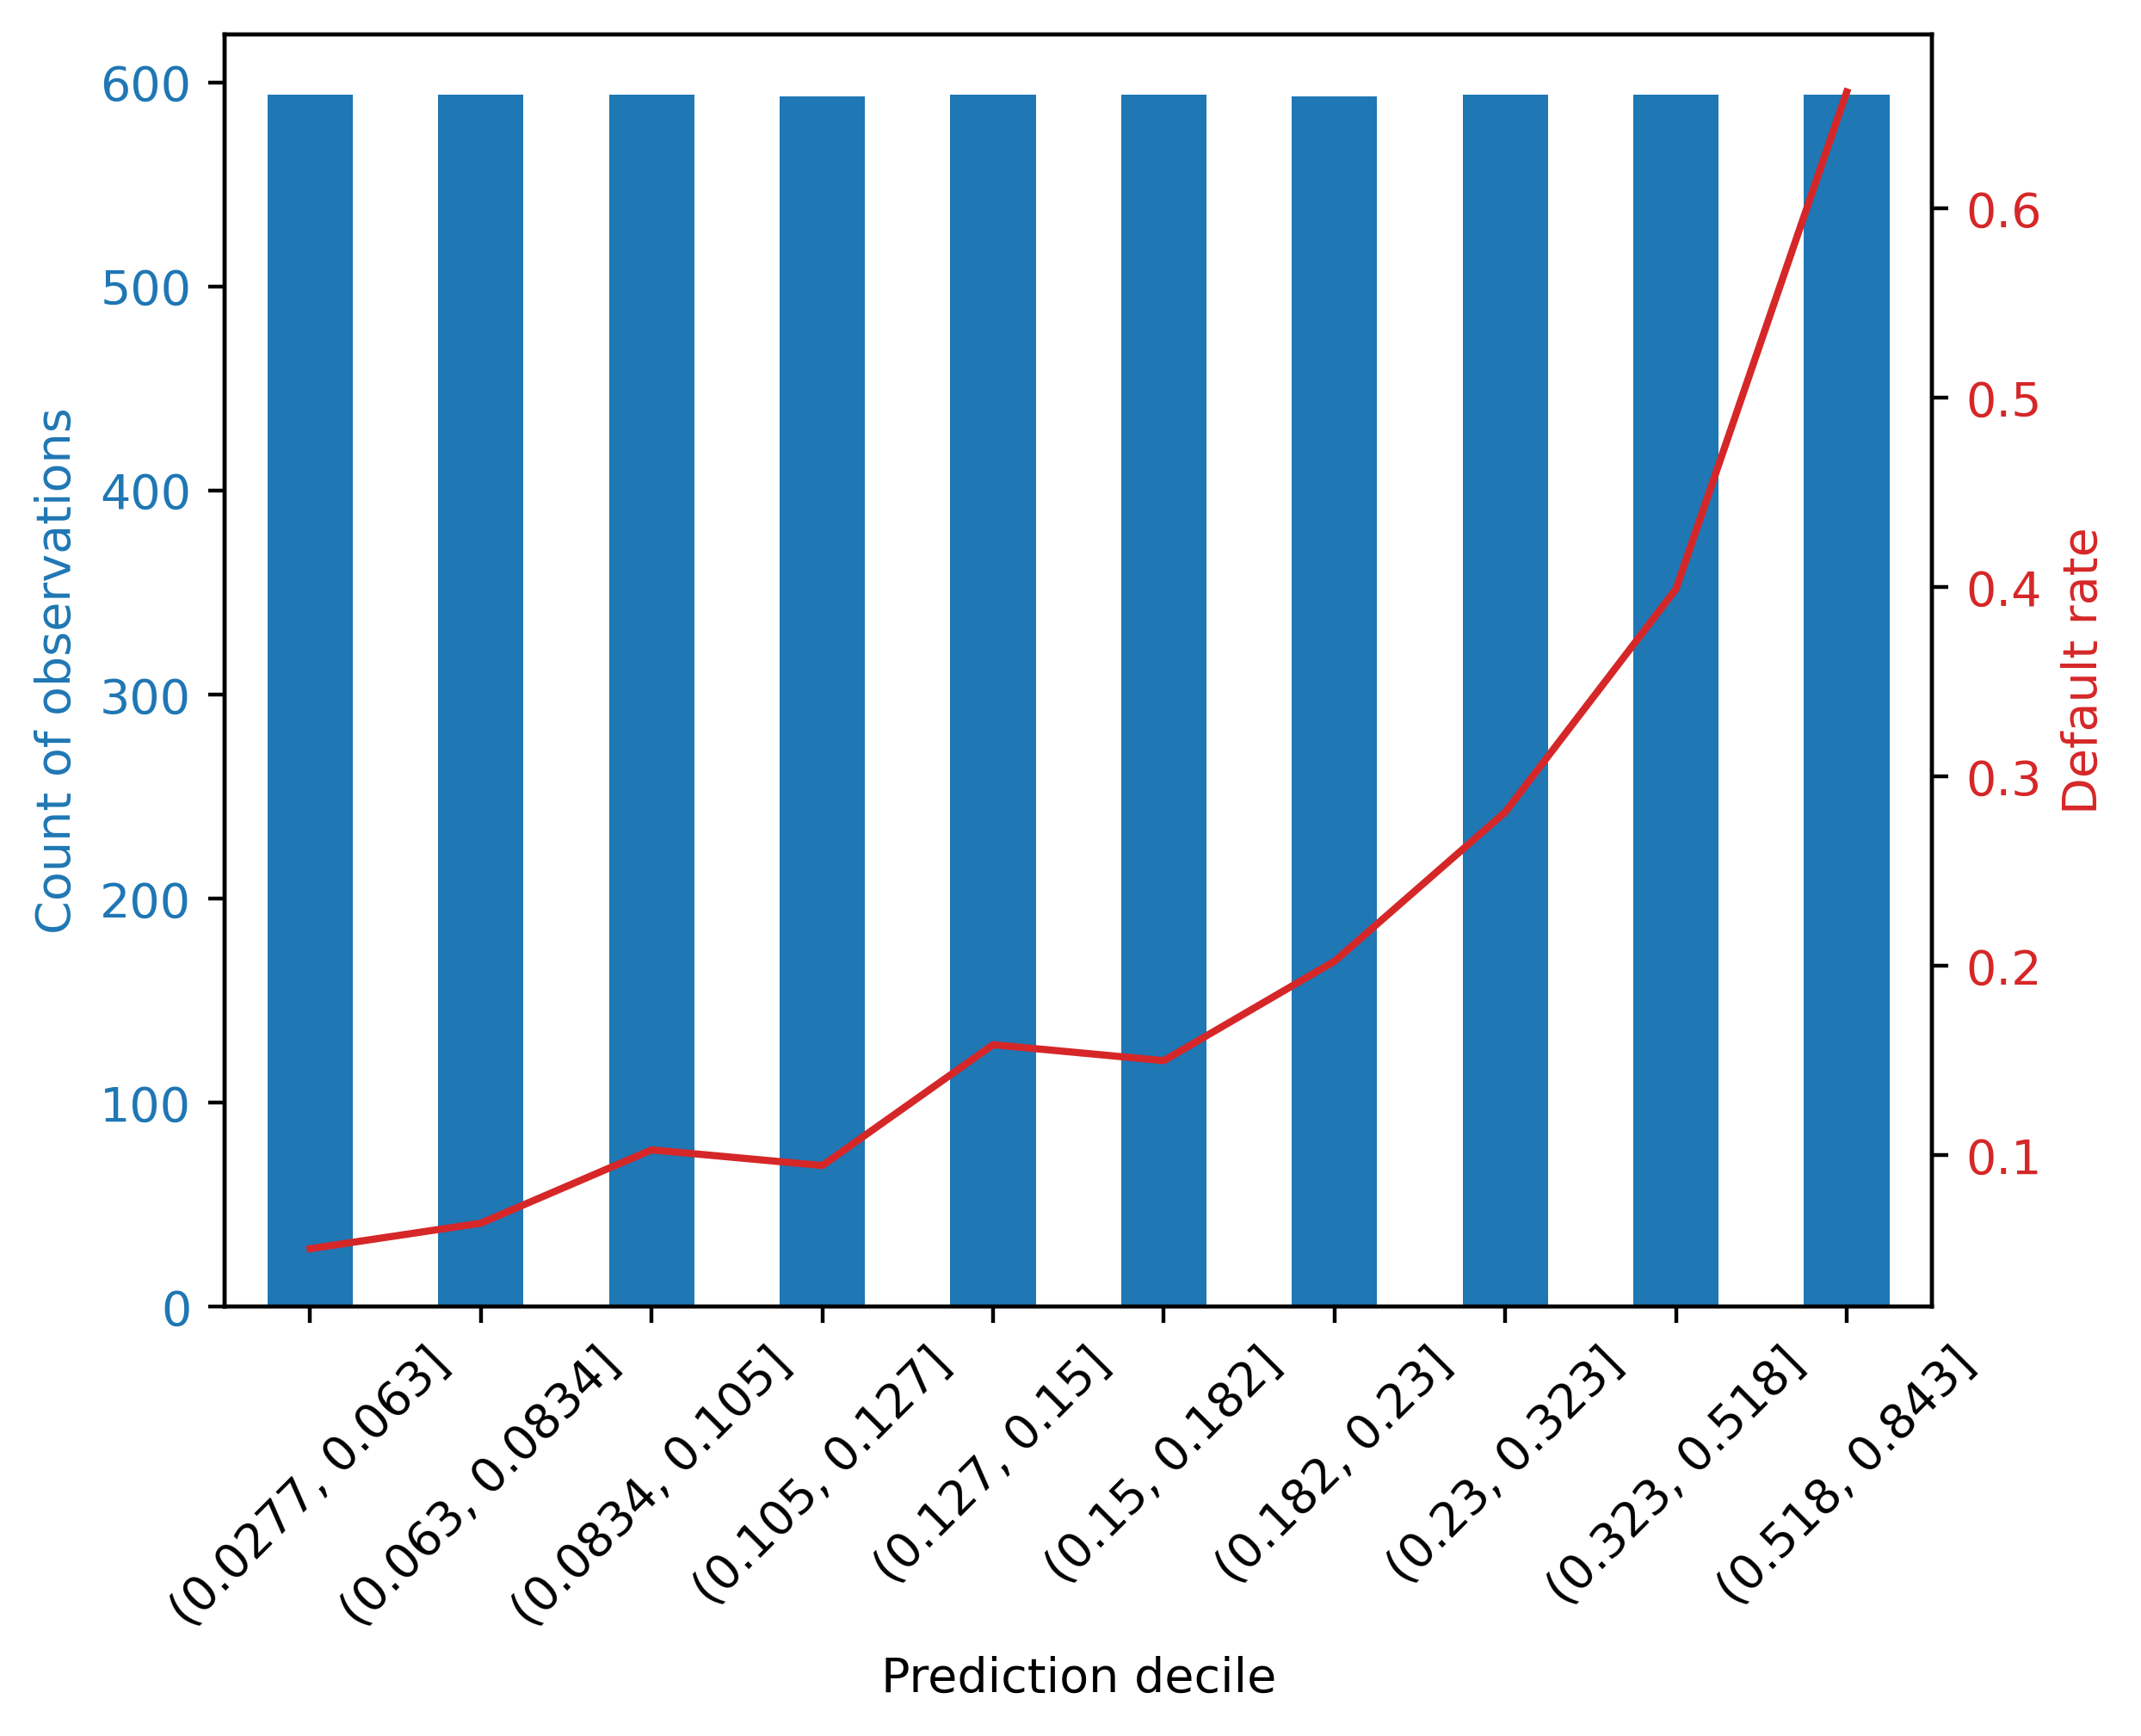

In [15]:
ax_1 = plt.axes()
color_1 = 'tab:blue'
gr_df[('Outcome', 'count')].plot.bar(ax=ax_1, color=color_1)
ax_1.set_ylabel('Count of observations', color=color_1)
ax_1.tick_params(axis='y', labelcolor=color_1)
ax_1.tick_params(axis='x', labelrotation = 45)

ax_2 = ax_1.twinx()  # 同一图表，两个y轴
color_2 = 'tab:red'
gr_df[('Outcome', 'mean')].plot(ax=ax_2, color=color_2)
ax_2.set_ylabel('Default rate', color=color_2)
ax_2.tick_params(axis='y', labelcolor=color_2)

In [16]:
equal_intervals, equal_interval_bin_edges = \
 pd.cut(x=test_set_pred_proba,\
 bins=5,\
 retbins=True)

In [18]:
test_set_bins_df =\
pd.DataFrame({'Predicted probability':test_set_pred_proba,\
              'Prediction bin':equal_intervals,\
              'Outcome':y_test_all})
test_set_bins_df.head()

,Predicted probability,Prediction bin,Outcome
0,0.688628,"(0.68, 0.843]",0
1,0.634731,"(0.517, 0.68]",0
2,0.053137,"(0.0279, 0.191]",0
3,0.842597,"(0.68, 0.843]",1
4,0.325197,"(0.191, 0.354]",0


In [19]:
test_set_equal_gr = test_set_bins_df.groupby('Prediction bin')
gr_eq_df = test_set_equal_gr.agg({'Outcome':['count', 'mean']})
gr_eq_df

/var/folders/dj/nbjnfkrd4kqdr9tqs5m_hrsr0000gn/T/ipykernel_78803/2042368696.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_set_equal_gr = test_set_bins_df.groupby('Prediction bin')


Outcome          
                  count      mean
Prediction bin                   
(0.0279, 0.191]    3712  0.104795
(0.191, 0.354]     1196  0.258361
(0.354, 0.517]      430  0.446512
(0.517, 0.68]       250  0.560000
(0.68, 0.843]       350  0.728571

In [20]:
p = gr_eq_df[('Outcome', 'mean')].values
n = gr_eq_df[('Outcome', 'count')].values
std_err = np.sqrt(p * (1-p) / n)
std_err

array([0.00502722, 0.01265739, 0.02397377, 0.03139427, 0.02377004])

Notice that for the bins with higher score ranges and fewer samples, the
standard error is larger. It will be helpful to visualize these standard errors with
the default rates

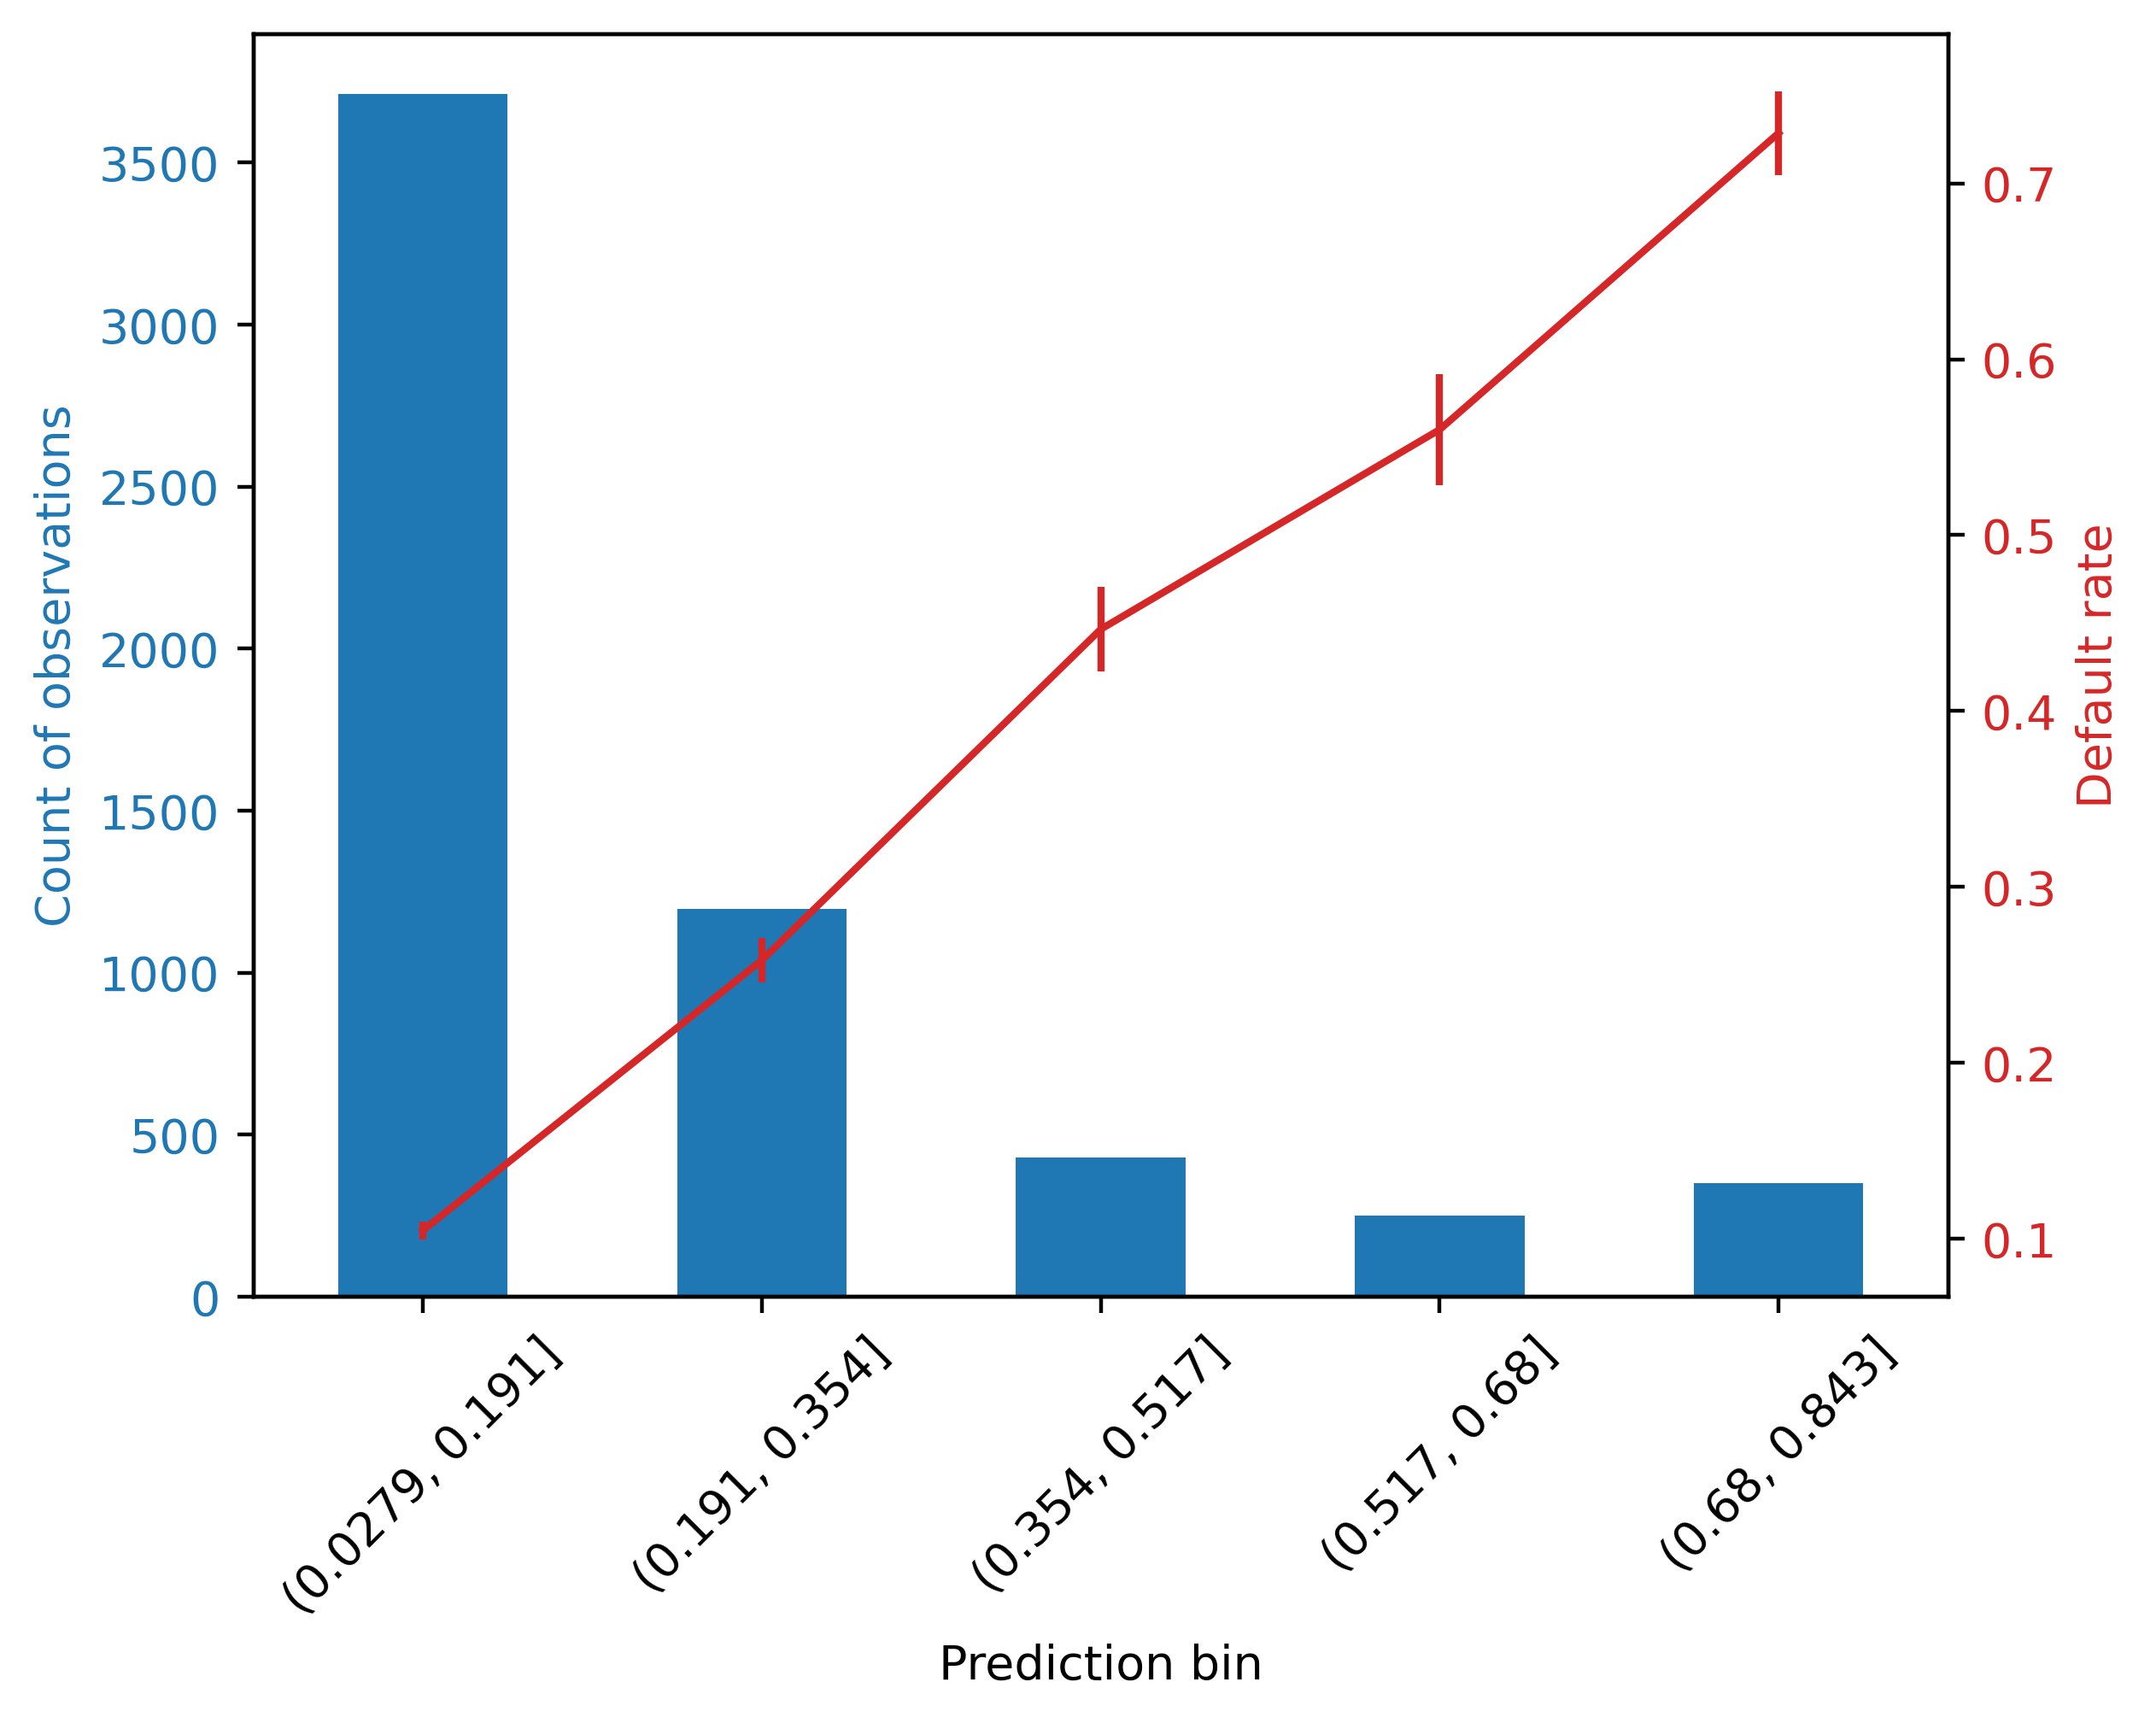

In [21]:
ax_1 = plt.axes()
color_1 = 'tab:blue'
gr_eq_df[('Outcome', 'count')].plot.bar(ax=ax_1, color=color_1)
ax_1.set_ylabel('Count of observations', color=color_1)
ax_1.tick_params(axis='y', labelcolor=color_1)
ax_1.tick_params(axis='x', labelrotation = 45)

ax_2 = ax_1.twinx()
color_2 = 'tab:red'
gr_eq_df[('Outcome', 'mean')].plot(ax=ax_2, color=color_2, yerr=std_err)
ax_2.set_ylabel('Default rate', color=color_2)
ax_2.tick_params(axis='y', labelcolor=color_2)

We can see that the number of samples is pretty different among the
different bins, in contrast to the quantile approach. While there are relatively few
samples in the higher score bins, leading to a larger standard error, the error bars on
the plot of default rate are still small compared to the overall trend of an increasing
default rate from lower to higher score bins, so we can be confident in this trend.

In [ ]:
sloping risk: 曲线向上，说明模型ranking能力准确

# Calibration of Predicted Probabilities
ECE（Expected Calibration Error）

用于长期的monitor，ECC如果大了，就要retrain model

ECE要基于bin，一般用十分位的等量分桶（Quantile Binning）：即使用 pd.qcut，保证每个桶里的样本数 F_i 基本一致。等距分桶（Uniform Binning）：即使用 pd.cut，将 0 到 1 的概率区间等分成 10 份（如 0-0.1, 0.1-0.2...）。这种方法在数据分布不均匀时（比如 90% 的样本预测值都在 0.1 以下），会导致某些桶里几乎没有样本，计算出的误差会失真。

In [22]:
cal_df = test_set_gr.agg({'Outcome':['count', 'mean'],\
 'Predicted probability':'mean'})
cal_df

Outcome           Predicted probability
                    count      mean                  mean
Prediction decile                                        
(0.0277, 0.063]       594  0.050505              0.051289
(0.063, 0.0834]       594  0.063973              0.072878
(0.0834, 0.105]       594  0.102694              0.094526
(0.105, 0.127]        593  0.094435              0.115772
(0.127, 0.15]         594  0.158249              0.138396
(0.15, 0.182]         594  0.149832              0.165363
(0.182, 0.23]         593  0.202361              0.203339
(0.23, 0.323]         594  0.281145              0.271644
(0.323, 0.518]        594  0.398990              0.398954
(0.518, 0.843]        594  0.661616              0.684623

In [23]:
F = cal_df[('Outcome', 'count')].values/y_test_all.shape[0]
F

array([0.10003368, 0.10003368, 0.10003368, 0.09986527, 0.10003368,
       0.10003368, 0.09986527, 0.10003368, 0.10003368, 0.10003368])

In [24]:
ECE = np.sum(F * np.abs(cal_df[('Outcome', 'mean')] - cal_df[('Predicted probability', 'mean')]))
ECE

np.float64(0.010809950417603414)

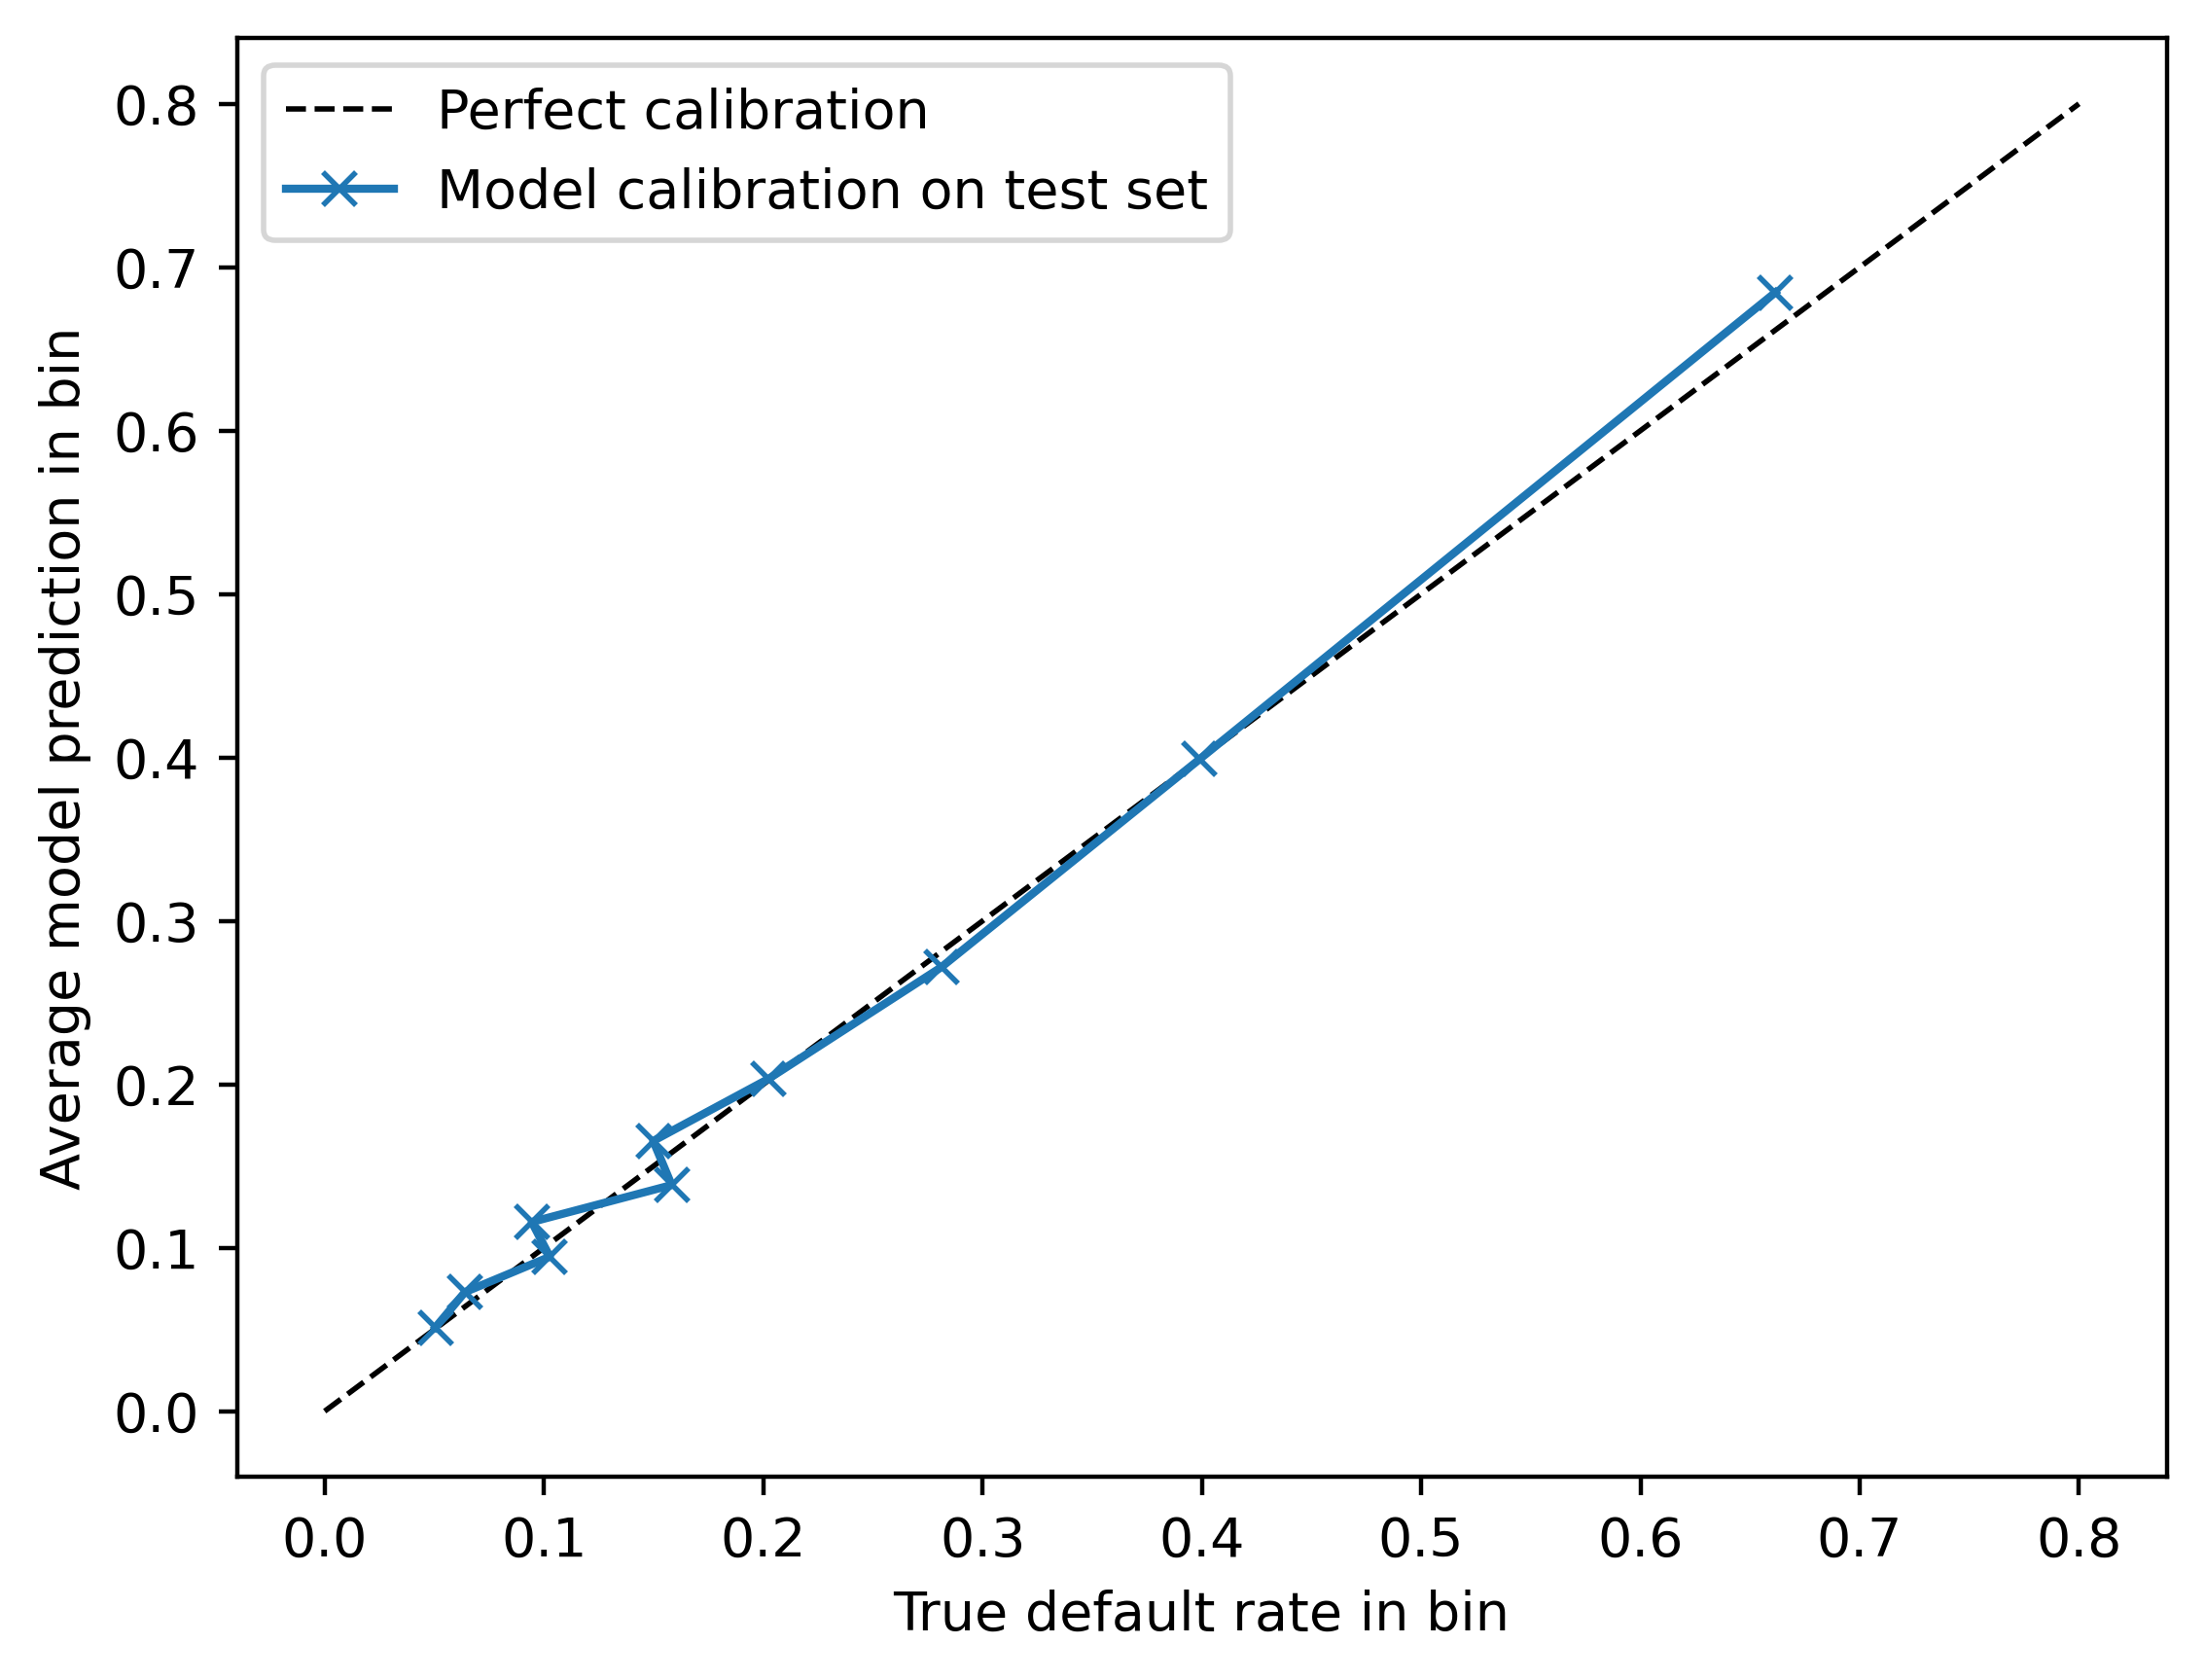

In [25]:
ax = plt.axes()
ax.plot([0, 0.8], [0, 0.8], 'k--', linewidth=1,
 label='Perfect calibration')
ax.plot(cal_df[('Outcome', 'mean')],\
 cal_df[('Predicted probability', 'mean')],\
 marker='x',\
 label='Model calibration on test set')
ax.set_xlabel('True default rate in bin')
ax.set_ylabel('Average model prediction in bin')
ax.legend()

# Financial Analysis

For a binary classification model such as that of the case study, here are a few
questions that the data scientist needs to know the answers to, in order to help the
client figure out how to use the model:
* What kinds of decisions does the client want to use the model to help
them make?
* How can the predicted probabilities of a binary classification model be used to
help make these decisions?
* Are they yes/no decisions? If so, then choosing a single threshold of predicted
probability will be sufficient.
* Are there more than two levels of activity that will be decided on, based on
model results? If so, then choosing two or more thresholds, to sort predictions
into low, medium, and high risk, for example, may be the solution. For instance,
predicted probabilities below 0.5 may be considered low risk, those between 0.5
and 0.75 medium risk, and those above 0.75 high risk.
* What are the costs of taking all the different courses of action that are available,
based on model guidance?
* What are the potential benefits to be gained from successful actions taken as a
result of model guidance?


# Financial Conversation with the Client
We ask the case study client about the points outlined above and learn the following:
for credit accounts that are at a high risk of default, the client is designing a new
program to provide individualized counseling for the account holder, to encourage
them to pay their bill on time or provide alternative payment options if that will
not be possible. Credit counseling is performed by trained customer service
representatives who work in a call center. The cost per counseling session is NT$7,500
and the expected success rate of a session is 70%, meaning that on average 70% of
the recipients of phone calls offering counseling will pay their bill on time, or make
alternative arrangements that are acceptable to the creditor. The potential benefits of
successful counseling are that the amount of an account's monthly bill will be realized
as savings, if it was going to default but instead didn't, as a result of the counseling.
Currently, the monthly bills for accounts that default are reported as losses.

After having the preceding conversation with the client, we have the materials we
need to make a financial analysis. The client would like us to help them decide which
members to contact and offer credit counseling to. If we can help them narrow down
the list of people who will be contacted for counseling, we can help save them money
by avoiding unnecessary and expensive contacts. The clients' limited resources for
counseling will be more appropriately spent on accounts that are at higher risk of
default. This should create greater savings due to prevented defaults. Additionally,
the client lets us know that our analysis can help them request a budget for the
counseling program, if we can give them an idea of how many counseling sessions it
would be worthwhile to offer.

As we proceed to the financial analysis, we see that the decision that the model will
help the client make, on an account by account basis, is a yes/no decision: whether to
offer counseling to the holder of a given account. Therefore, our analysis should focus
on finding an appropriate threshold of predicted probability, by which we may divide
our accounts into two groups: higher-risk accounts that will receive counseling and
lower-risk ones that won't.

# Characterizing Costs and Savings
The connection between model output and business decisions the client will make
comes down to selecting a threshold for the predicted probabilities. Therefore, in this
exercise, we will characterize the expected costs of the counseling program, in terms
of costs of offering individual counseling sessions, as well as the expected savings,
in terms of prevented defaults, at a range of thresholds. There will be different
costs and savings at each threshold, because each threshold is expected to result
in a different number of positive predictions, as well as a different number of true
positives within these. 

In [31]:
# Create a range of thresholds to calculate expected costs and benefits of counseling
thresholds = np.linspace(0, 1, 101)
thresholds

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

Now, we need to know the potential savings of a prevented default. To calculate
this precisely, we would need to know the next month's monthly bill. However,
the client has informed us that this will not be available at the time they need to
create the list of account holders to be contacted. Therefore, in order to estimate
the potential savings, we will use the most recent monthly bill.

We will use the testing data to create this analysis, as this provides a simulation
of how the model will be used after we deliver it to the client: on new accounts
that weren't used for model training.

In [28]:
features_response[5]

'BILL_AMT1'

In [29]:
cost_per_counseling = 7500

In [30]:
effectiveness = 0.70

In [32]:
n_pos_pred = np.empty_like(thresholds)
total_cost = np.empty_like(thresholds)
n_true_pos = np.empty_like(thresholds)
total_savings = np.empty_like(thresholds)

In [33]:
counter = 0
for threshold in thresholds:
    pos_pred = test_set_pred_proba > threshold
    n_pos_pred[counter] = sum(pos_pred)
    total_cost[counter] = n_pos_pred[counter] * cost_per_counseling
    true_pos = pos_pred & y_test_all.astype(bool)
    n_true_pos[counter] = sum(true_pos)
    total_savings[counter] = np.sum(true_pos.astype(int)* X_test_all[:,5]* effectiveness)
    counter += 1

In [34]:
net_savings = total_savings - total_cost

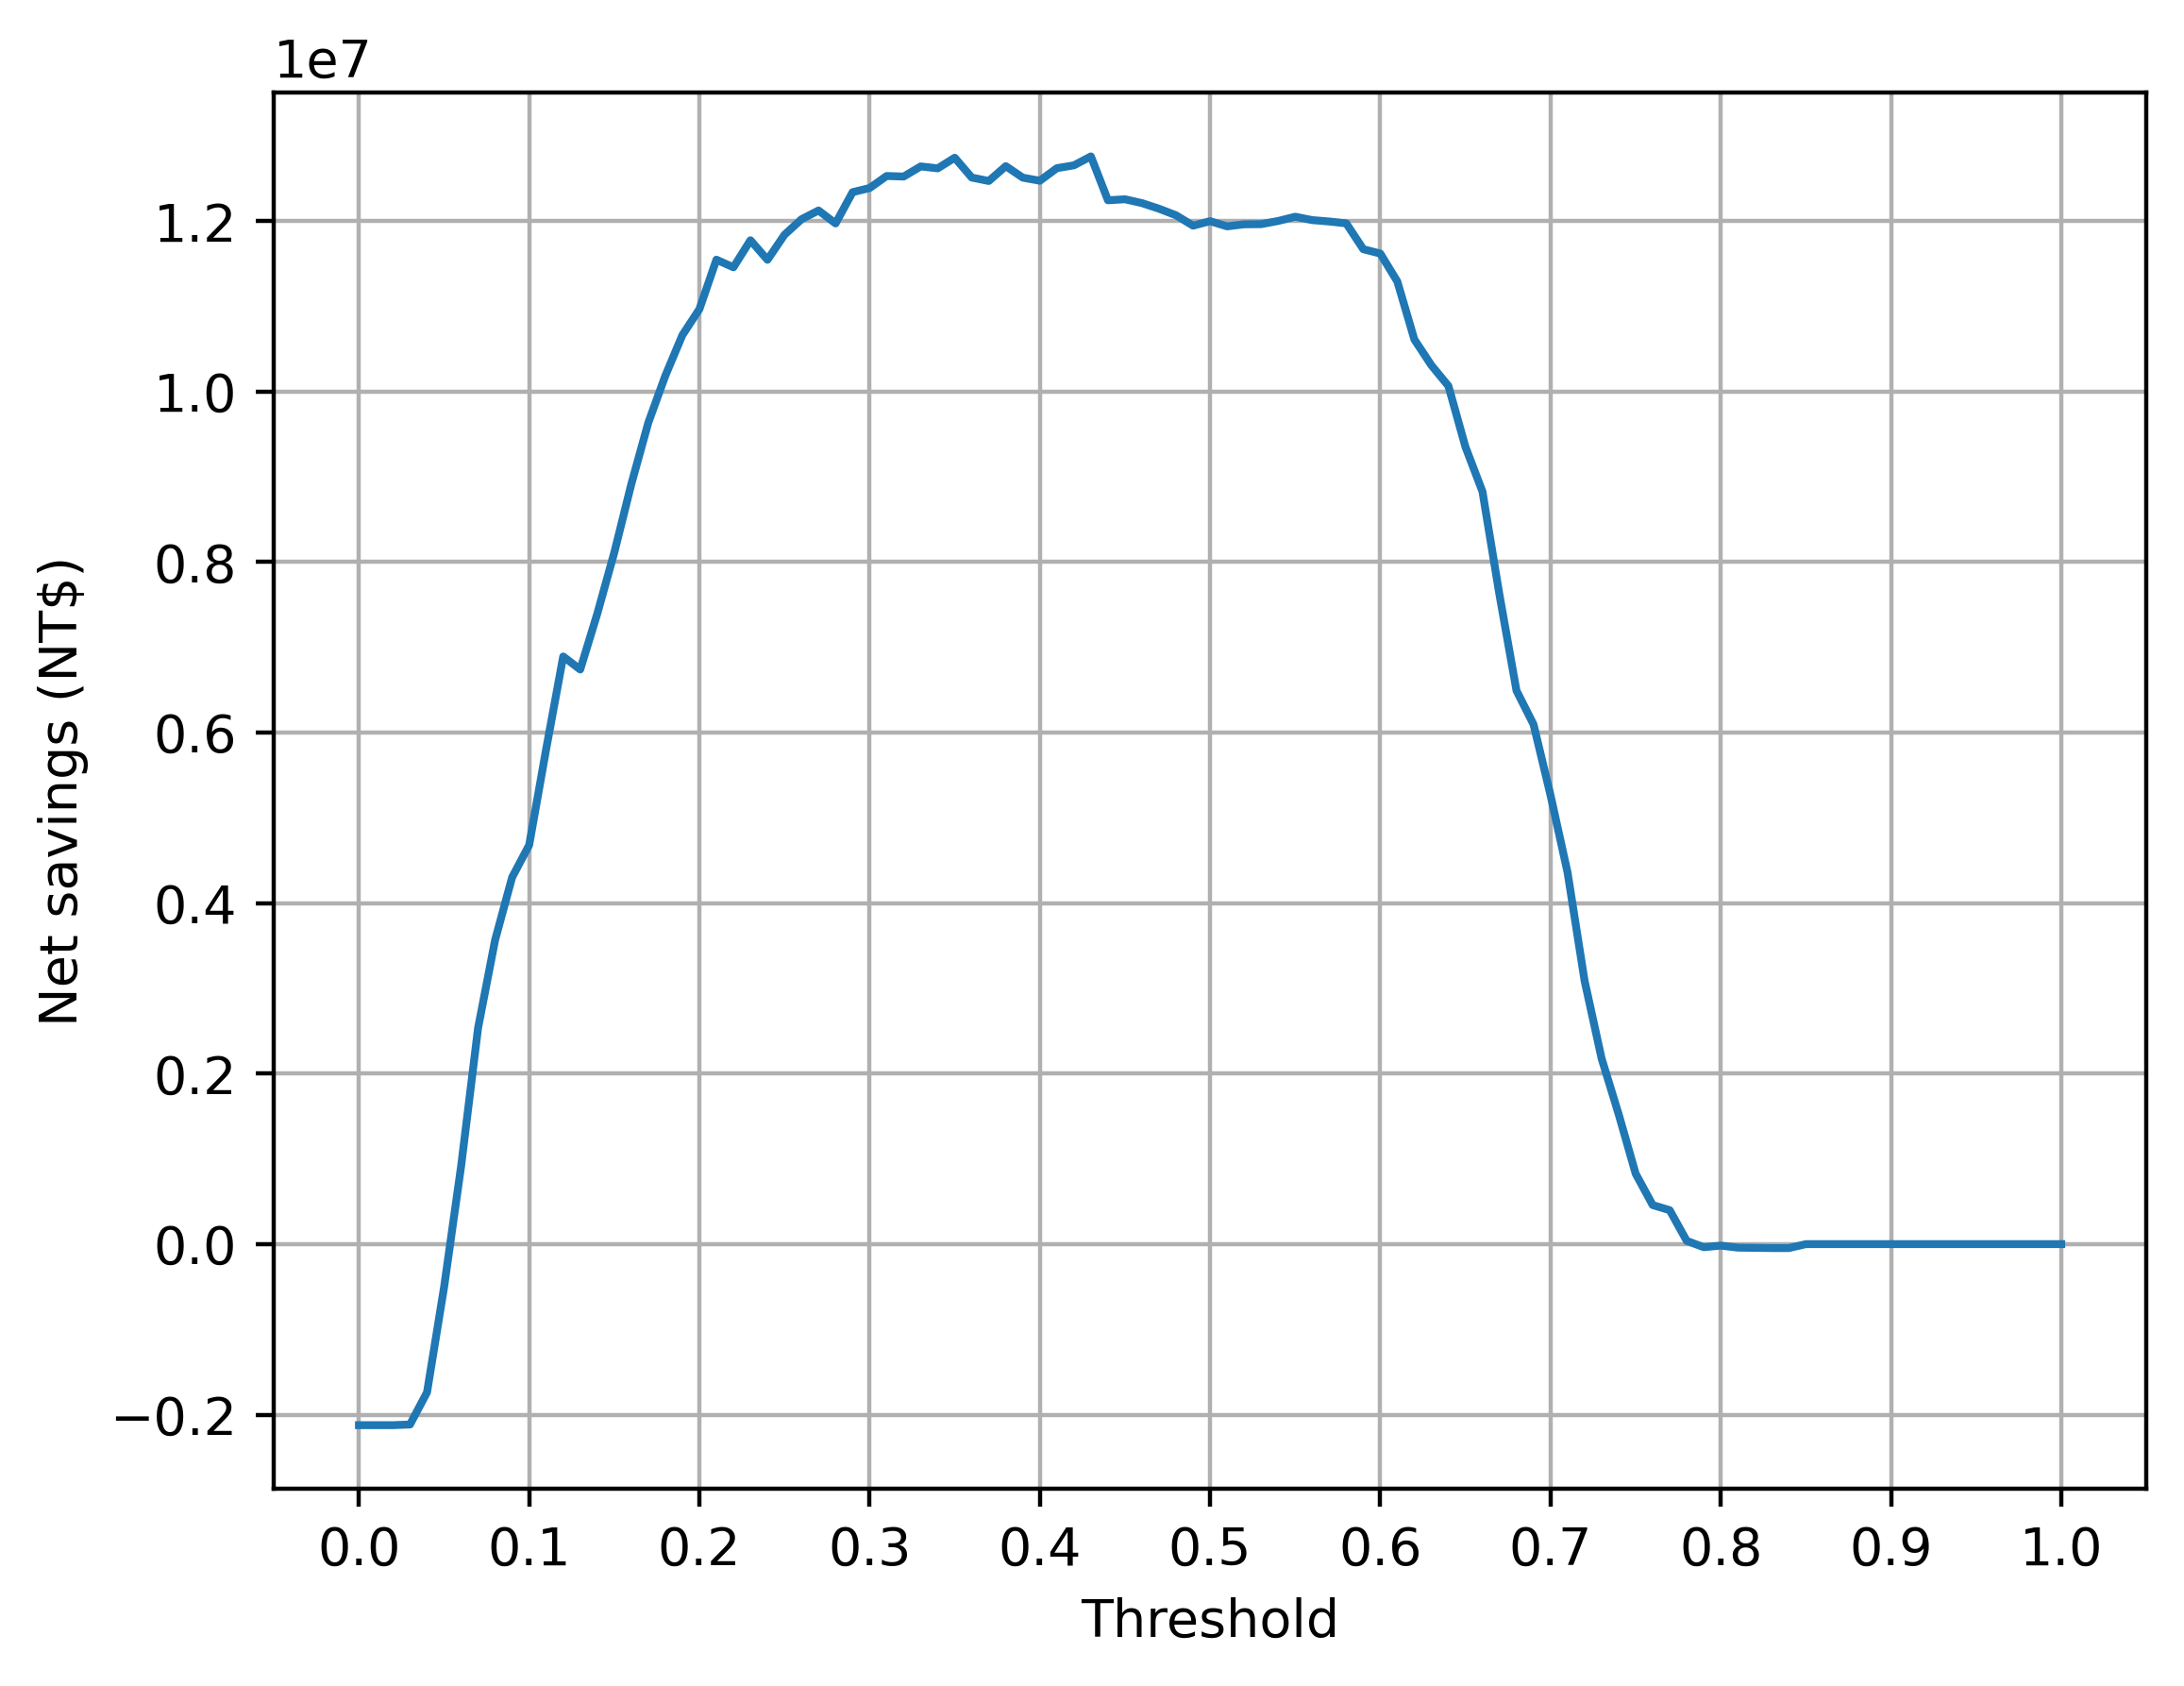

In [35]:
mpl.rcParams['figure.dpi'] = 400
plt.plot(thresholds, net_savings)
plt.xlabel('Threshold')
plt.ylabel('Net savings (NT$)')
plt.xticks(np.linspace(0,1,11))
plt.grid(True)

In [36]:
max_savings_ix = np.argmax(net_savings)

In [38]:
thresholds[max_savings_ix]

np.float64(0.43)

In [39]:
net_savings[max_savings_ix]

np.float64(12759053.0)

We see that the greatest net savings occurs at a threshold of 0.36. The amount of
net savings realized at this threshold is over NT$13 million, for this testing dataset of
accounts. These savings would need to be scaled by the number of accounts served
by the client, to estimate the total possible savings, assuming the data we are working
with is representative of all these accounts.
Note, however, that the savings are about the same up to a threshold of about 0.5, as
seen in the Figure above.
As the threshold increases, we are "raising the bar" for how risky a client must be,
in order for us to contact them and offer counseling. Increasing the threshold from
0.36 to 0.5 means we would be only contacting riskier clients whose probability is >
0.5. This means contacting fewer clients, reducing the upfront cost of the program.
The Figure above indicates that we may be still able to create roughly the same amount of
net savings, by contacting fewer people. While the net effect is the same, the initial
expenditure on counseling will be smaller. This may be desirable to the client. We
explore this concept further in the following activity

#  Deriving Financial Insights

The raw materials of the financial analysis are completed. However, in this activity,
your aim is to generate some additional insights from these results, to provide the
client with more context around how the predictive model we built can generate
value for them. In particular, we have looked at results for the testing set we reserved
from model building. The client may have more accounts than those they supplied
to us, that are representative of their business. You should report to them results
that could be easily scaled to however big their business is, in terms of the number
of accounts.

We can also help them understand how much this program will cost; while the
net savings are an important number to consider, the client will have to fund the
counseling program before any of these savings will be realized. Finally, we will link
the financial analysis back to standard machine learning model performance metrics.

Once you complete the activity, you should be able to communicate the initial cost
of the counseling program to the client, as well as obtain plots of precision and recall

In [40]:
# Using the testing set, calculate the cost of all defaults if there were no counseling program.
cost_of_defaults = np.sum(y_test_all * X_test_all[:,5])
cost_of_defaults 

np.float64(60587763.0)

In [41]:
# Calculate by what percent the cost of defaults can be decreased by the counseling program.
#The potential decrease in the cost of default is the greatest possible net savings
#of the counseling program, divided by the cost of all defaults in the absence of
#a program:
net_savings[max_savings_ix]/cost_of_defaults

np.float64(0.2105879532142489)

Results indicate that we can decrease the cost of defaults by 22% using a
counseling program, guided by predictive modeling.

In [42]:
#Calculate the net savings per account (considering all accounts it might be
#possible to counsel, in other words relative to the whole test set) at the
#optimal threshold.
net_savings[max_savings_ix]/len(y_test_all)

np.float64(2148.7121926574605)

Results like these help the client scale the potential amount of savings they could
create with the counseling program, to as many accounts as they serve.

Text(0, 0.5, 'Net savings per account (NT$)')

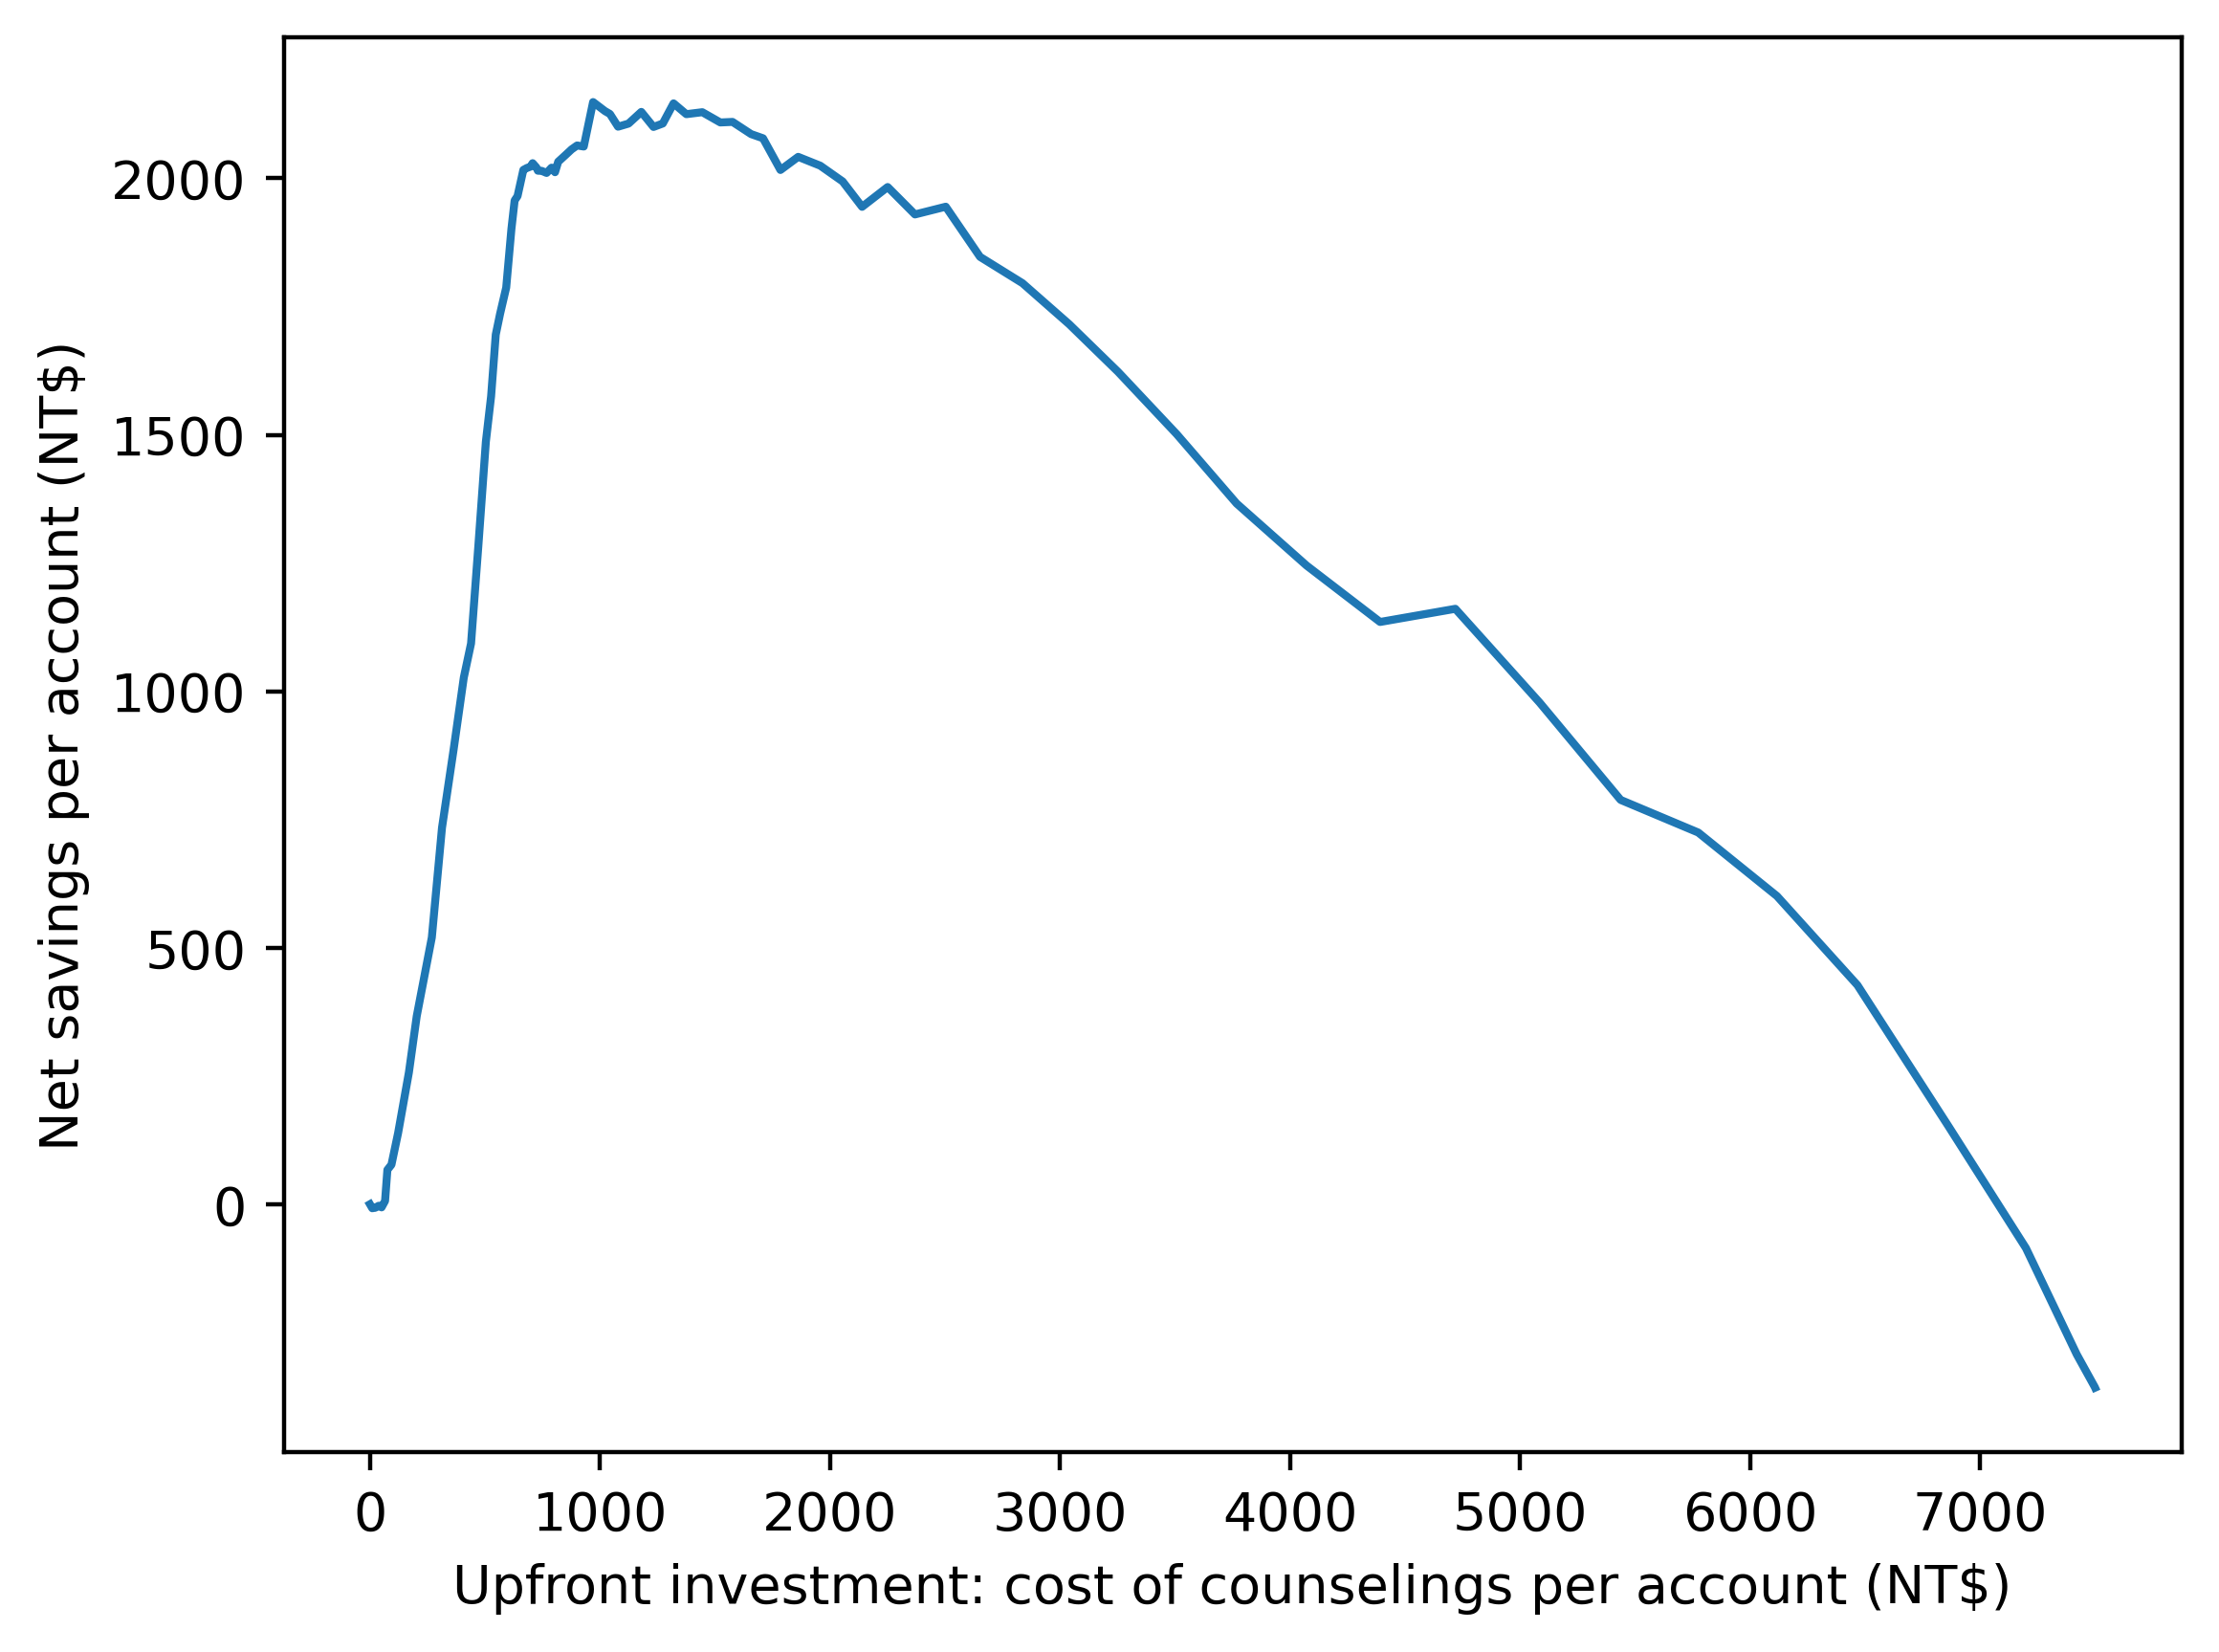

In [43]:
# Plot the net savings per account against the cost of counseling per account for
# each threshold.
plt.plot(total_cost/len(y_test_all), net_savings/len(y_test_all))
plt.xlabel('Upfront investment: cost of counselings per account (NT$)')
plt.ylabel('Net savings per account (NT$)')

This indicates how much money the client needs to budget to the counseling
program in a given month, to achieve a given amount of savings. It looks like the
greatest benefit can be created by budgeting up to about NT1300 per account
(you could find the exact budgeted amount corresponding to maximum net
savings using np.argmax). However, net savings are relatively flat for upfront
investments between NT$1000 and 2000, being lower outside that range. The
client may not actually be able to budget this much for the program. However,
this graphic gives them evidence to argue for a larger budget if they need to.

This result corresponds to our graphic from the previous exercise. Although
we've shown the optimal threshold is 0.36, it may be fine for the client to use
a higher threshold up to about 0.5, thus making fewer positive predictions,
offering counseling to fewer account holders, and having a smaller upfront
program cost. Figure above shows how this plays out in terms of cost and net
savings per account.

Text(0.5, 0, 'Threshold')

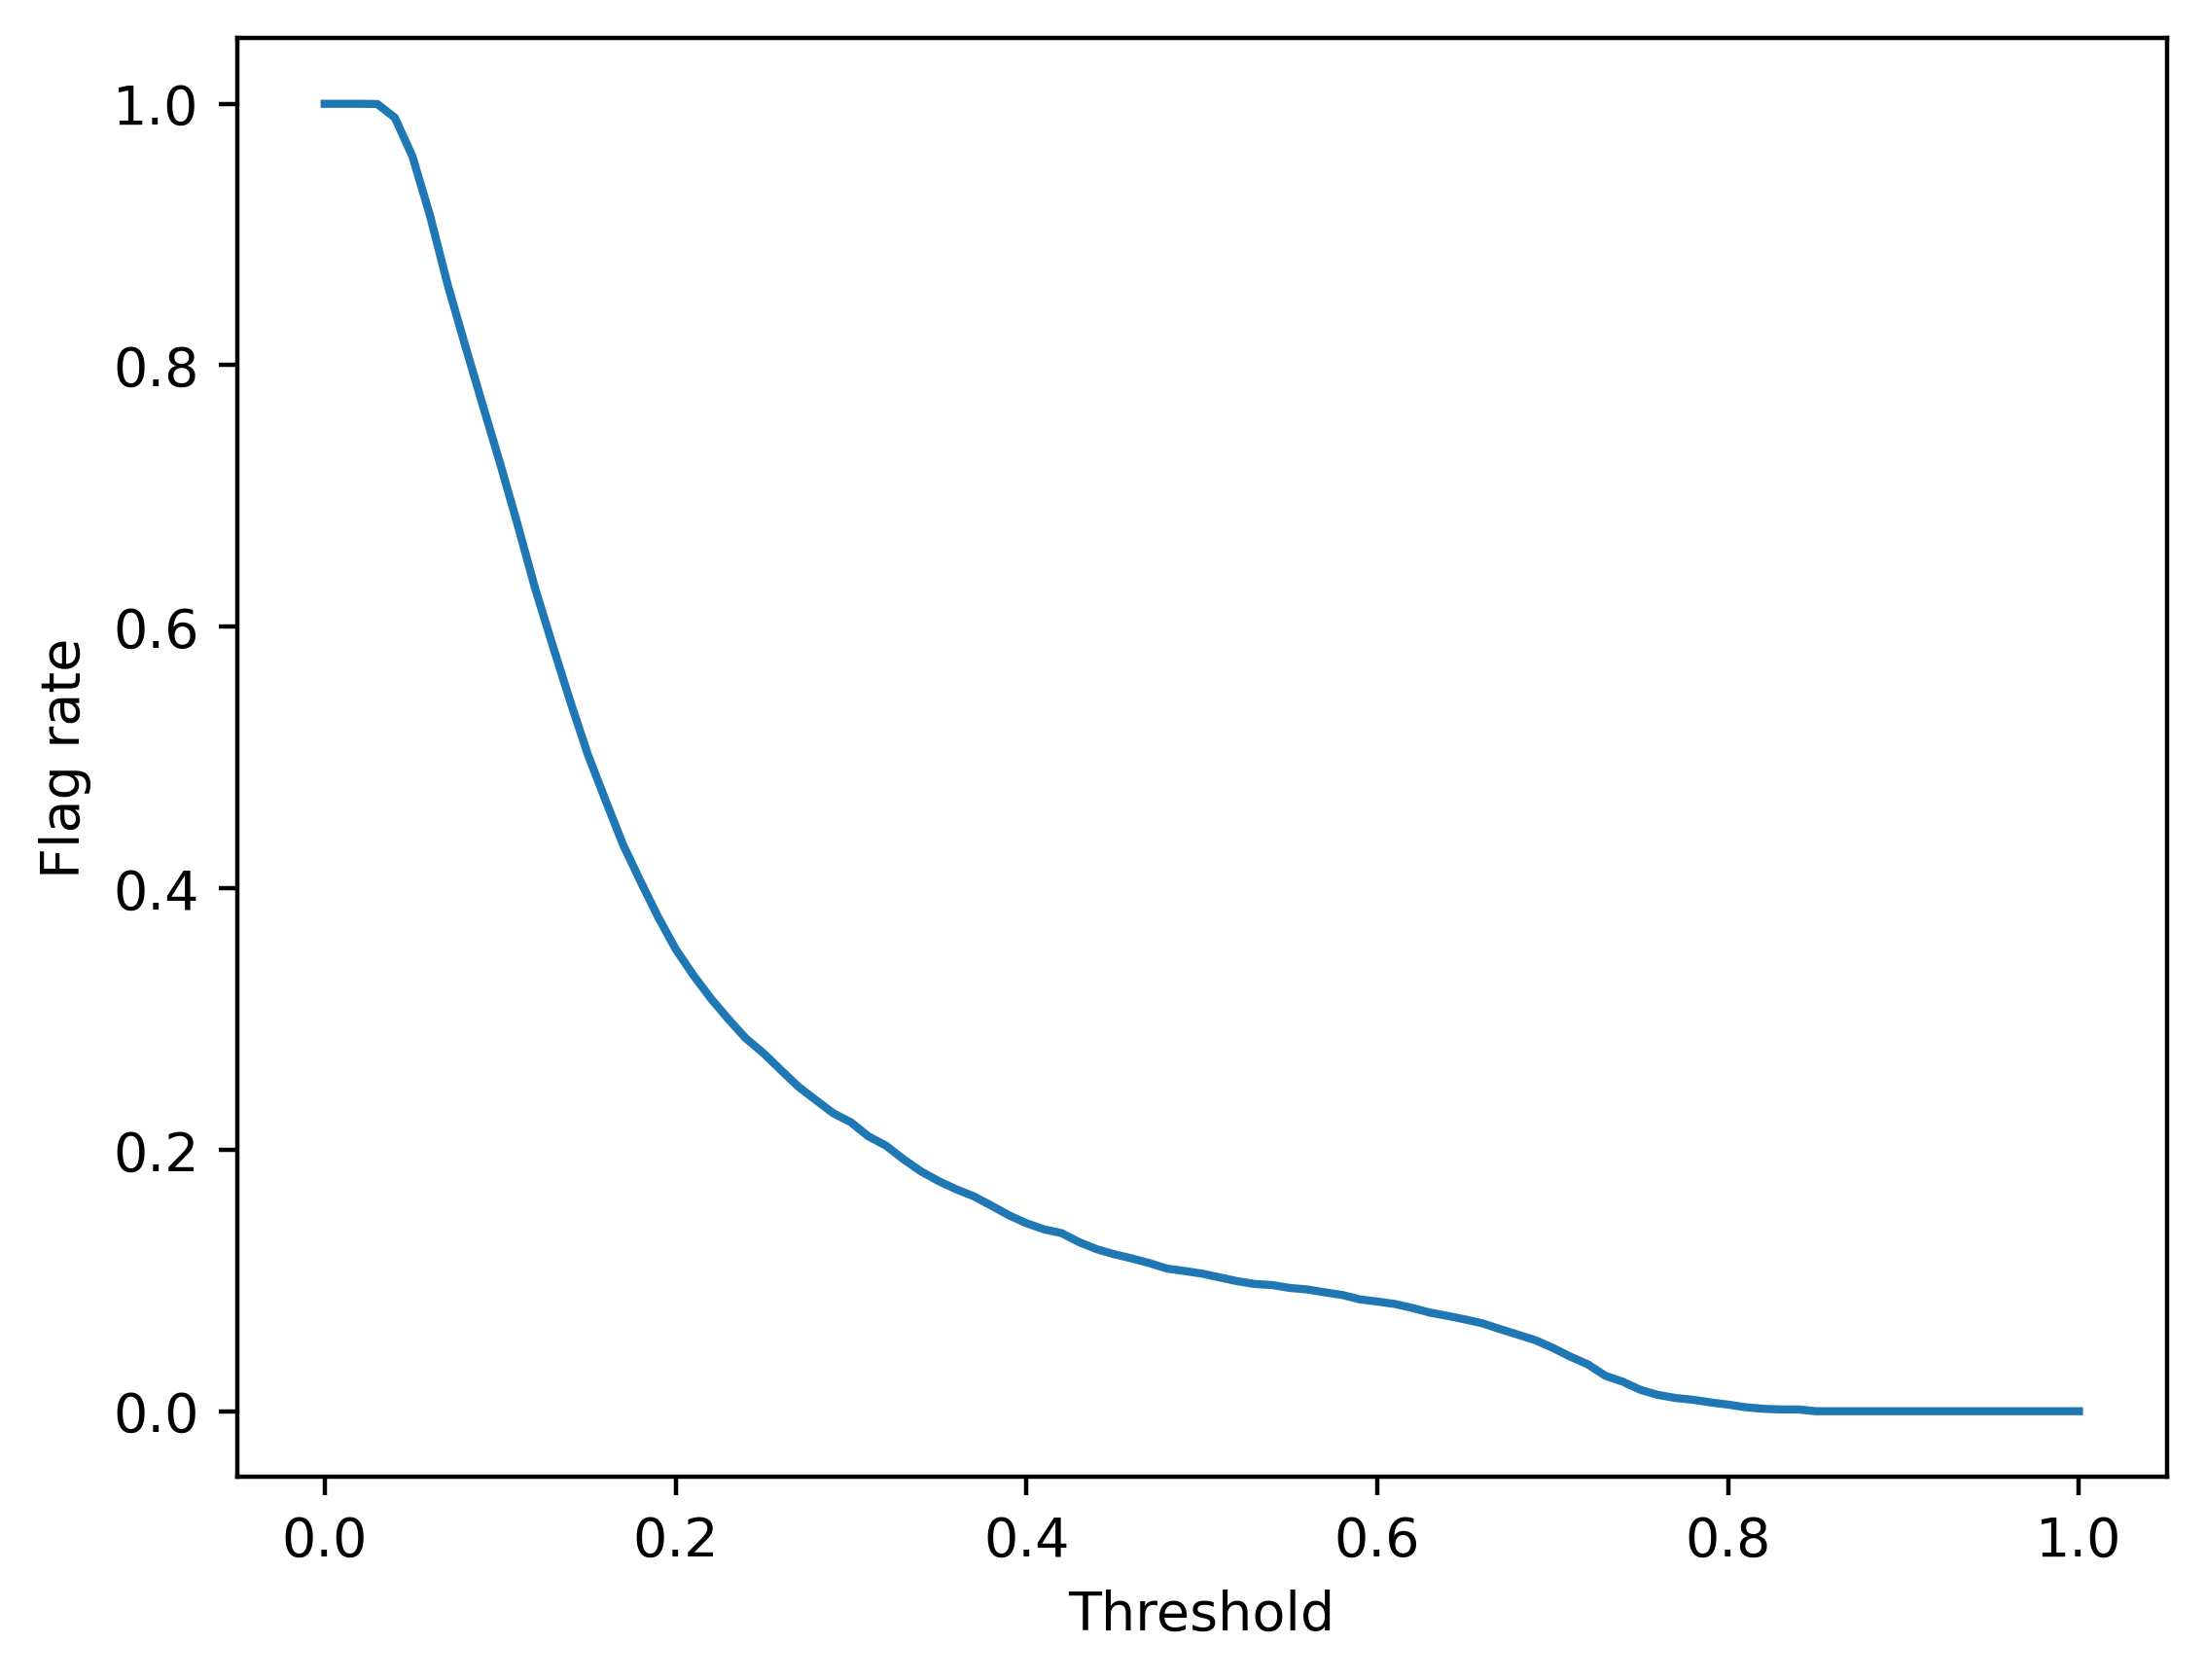

In [44]:
#Plot the fraction of accounts predicted as positive (this is called the "flag rate") at
#each threshold.
plt.plot(thresholds, n_pos_pred/len(y_test_all))
plt.ylabel('Flag rate')
plt.xlabel('Threshold')

It appears that at
the optimal threshold of 0.36, only about 20% of accounts will be flagged for
counseling. This shows how using a model to prioritize accounts for counseling
can help focus on the right accounts and reduce wasted resources. Higher
thresholds, which may result in nearly optimal savings up to a threshold of about
0.5 result in lower flag rates.

/var/folders/dj/nbjnfkrd4kqdr9tqs5m_hrsr0000gn/T/ipykernel_78803/4267989844.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(n_true_pos/sum(y_test_all),np.divide(n_true_pos, n_pos_pred))


Text(0, 0.5, 'Precision')

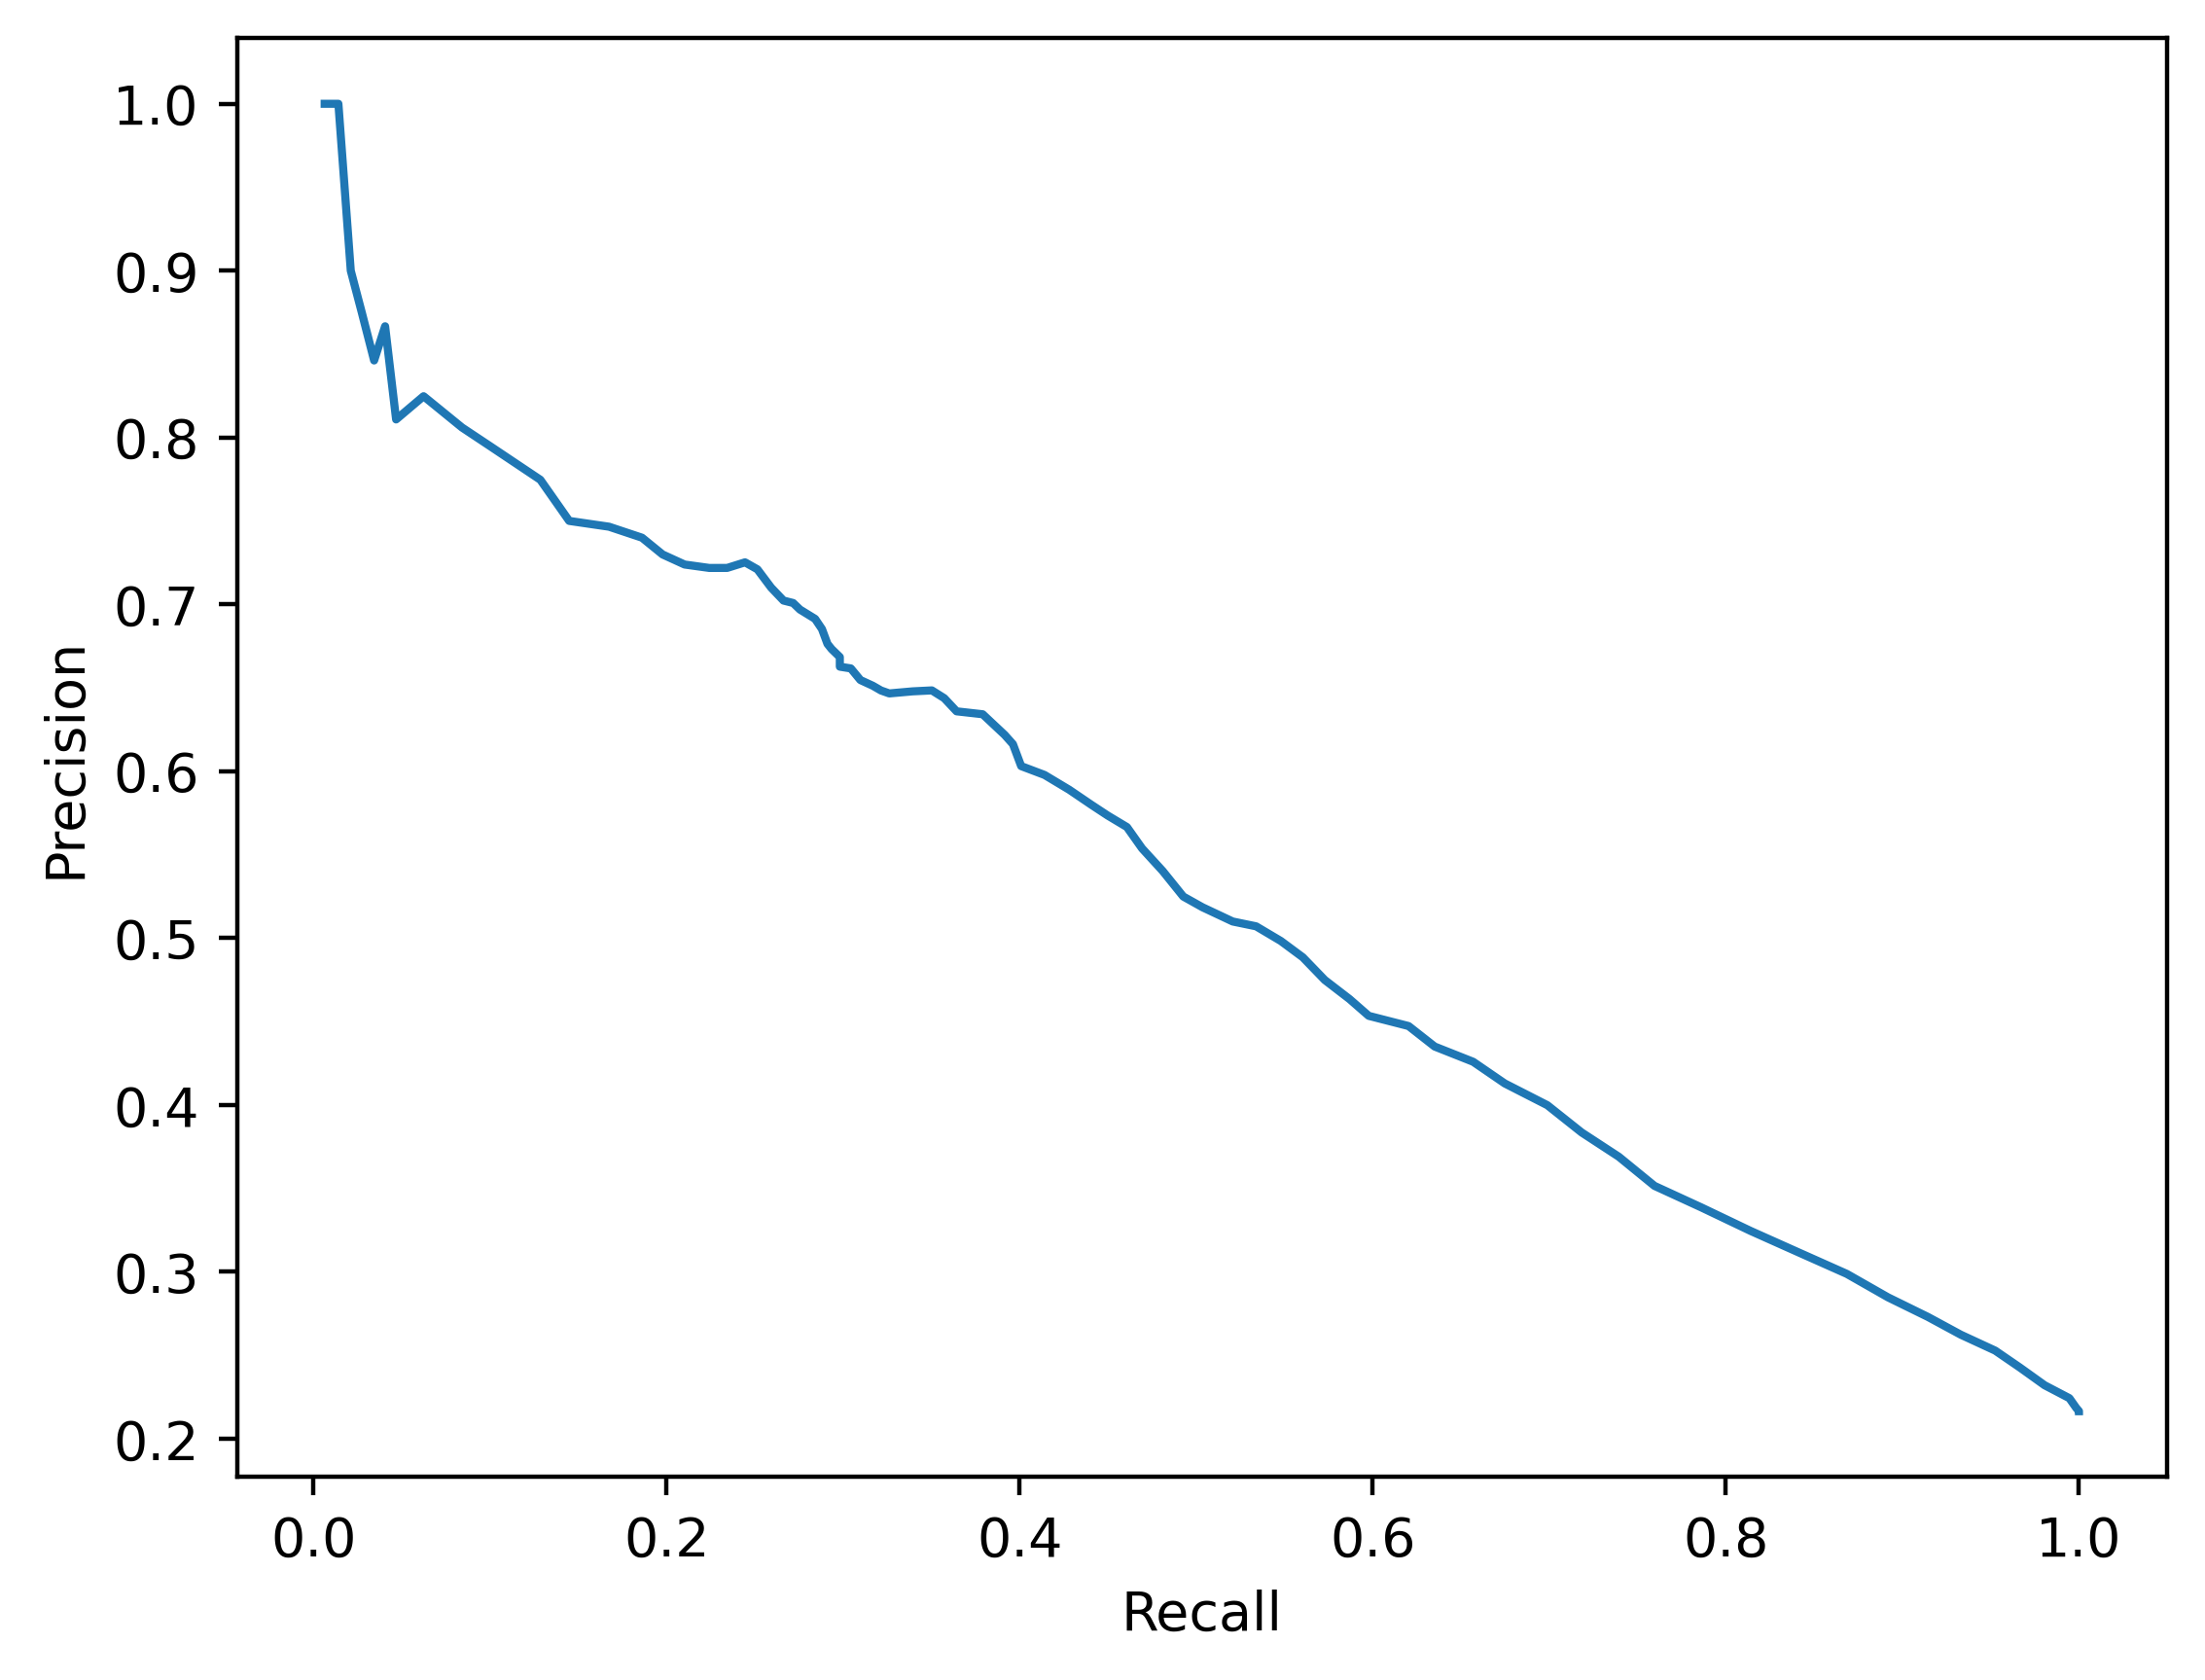

In [45]:
# Plot a precision-recall curve for the testing data
plt.plot(n_true_pos/sum(y_test_all),np.divide(n_true_pos, n_pos_pred))
plt.xlabel('Recall')
plt.ylabel('Precision')

Figure shows that in order to start getting a true positive rate (that is, recall)
much above 0, we need to accept a precision of about 0.8 or lower.
Precision and recall have a direct link to the cost and savings of the program: the
more precise our predictions are, the less money we are wasting on counseling
due to incorrect model predictions. And, the higher the recall, the more savings
we can create by successfully identifying accounts that would default. Compare
the code in this step to the code used to calculate costs and savings in the
previous exercise to see this.

/var/folders/dj/nbjnfkrd4kqdr9tqs5m_hrsr0000gn/T/ipykernel_78803/3821654614.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(thresholds, np.divide(n_true_pos, n_pos_pred),


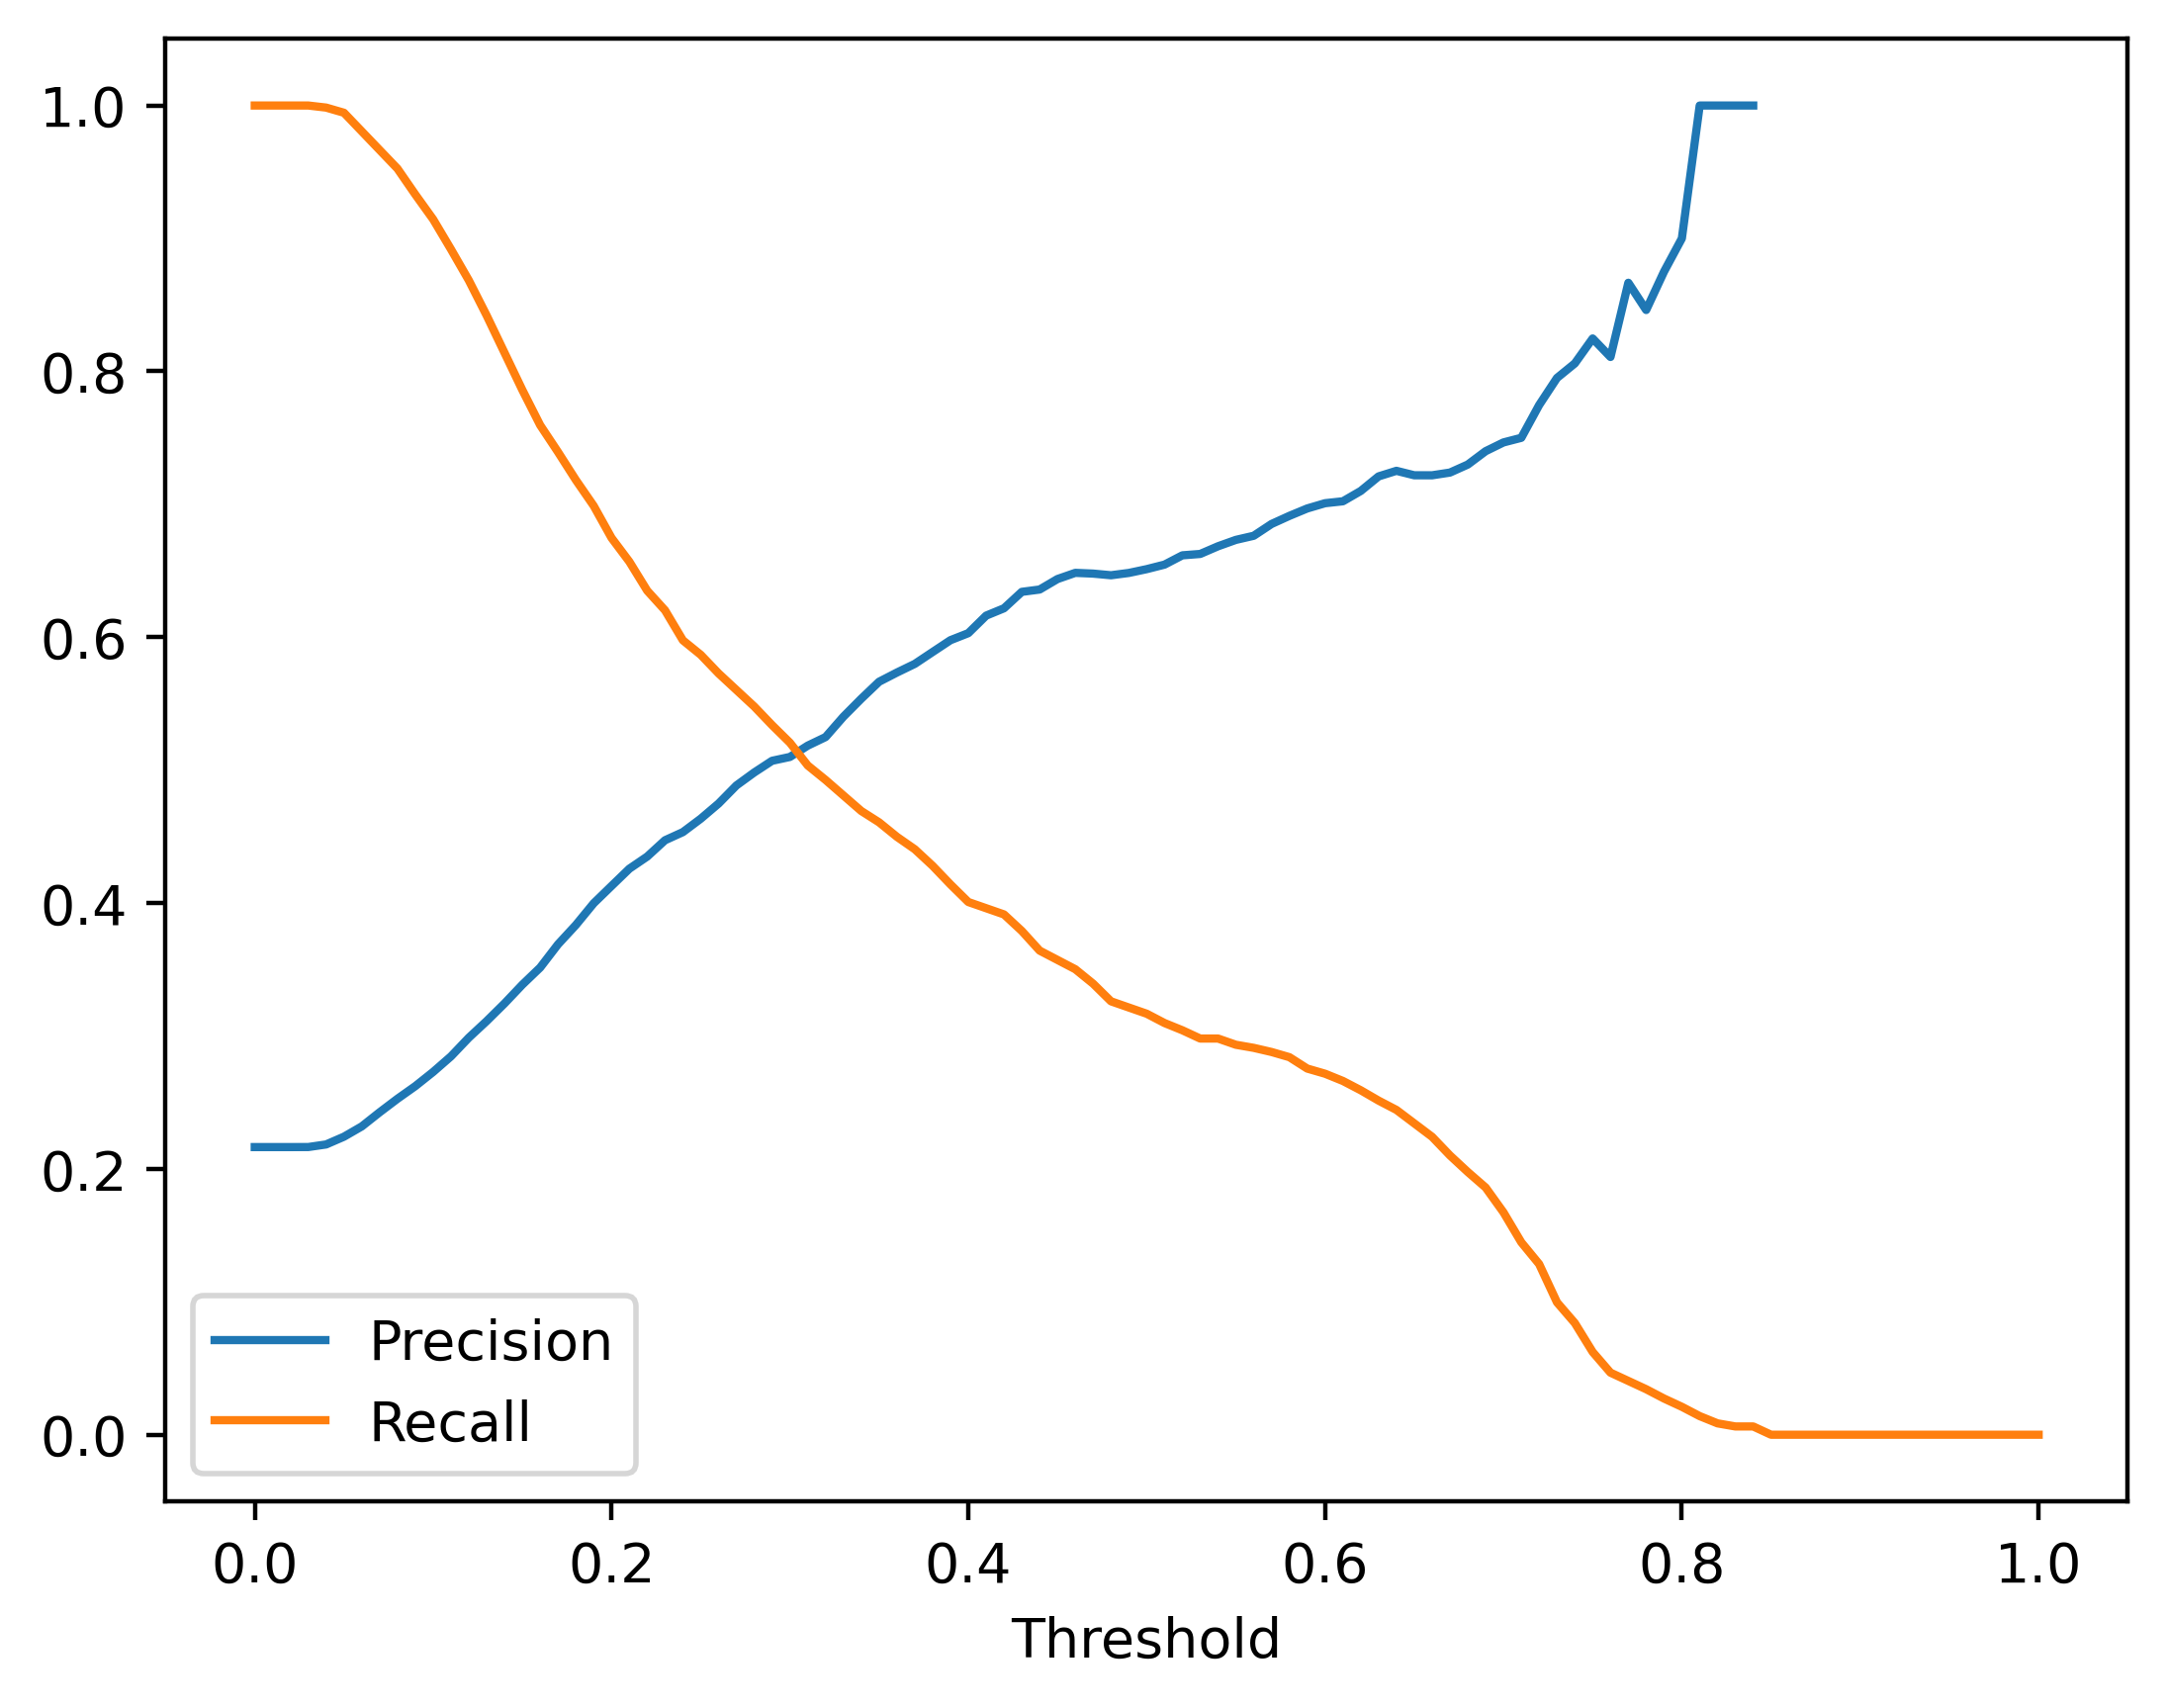

In [46]:
# Plot precision and recall separately on the y-axis against threshold on the x-axis.
plt.plot(thresholds, np.divide(n_true_pos, n_pos_pred),
 label='Precision')
plt.plot(thresholds, n_true_pos/sum(y_test_all),
 label='Recall')
plt.xlabel('Threshold')
plt.legend()

This plot sheds some light on why the optimal threshold turned out to be 0.36.
While the optimal threshold also depends on the financial analysis of costs and
savings, we can see here that the steepest part of the initial increase in precision,
which represents the correctness of positive predictions and is therefore a
measure of how cost-effective the model-guided counseling can be, happens up
to a threshold of about 0.36.

# Deliverables

Along with trained models saved to disk, or other data products or services
you may provide to the client, you will probably also want to create a presentation,
typically a slide show, detailing your progress. Contents of such presentations usually
include a problem statement, results of data exploration and cleaning, a comparison
of the performance of different models you built, model explanations such as SHAP
values, and the financial analysis which shows how valuable your work is. As you craft
presentations of your work, it's usually better to tell your story with pictures as opposed
to a lot of text. 

Another important consideration for the discussion of deliverables is: what format
should the predictions be delivered in? A typical delivery format for predictions from a
binary classification model, such as that we've created for the case study, is to rank
accounts by their predicted probability of default. The predicted probability should
be supplied along with the account ID and whatever other columns the client would
like. This way, when the call center is working their way through the list of account
holders to offer counseling to, they can contact those at highest risk for default first
and proceed to lower-priority account holders as time and resources allow. The client
should be informed of which threshold to use for predicted probabilities, to result in
the highest net savings. This threshold would represent the stopping point on the list
of account holders to contact if it is ranked on the predicted probability of default.


# Model Monitoring

Depending on how long the client has engaged the data scientist for, it is always
beneficial to monitor the performance of the model over time, as it is being used.
Does predictive capability remain the same or degrade over time? When assessing
this for the case study, it would be important to keep in mind that if account holders
are receiving counseling, their probability of default would be expected to be lower
than the predicted probability indicates, due to the intended effects of the new
counseling program. For this reason, and to test the effectiveness of the counseling
program, it is good practice to reserve a randomly chosen portion of account holders
who will not receive any counseling, regardless of credit default risk. This group would
be known as the control group and should be small compared to the rest of the
population who receives counseling, but large enough to draw statistically significant
inferences from.

While it's beyond the scope of this book to go into details about how to design and
use a control group, suffice to say here that model predictive capability could be
assessed on the control group since they have received no counseling, similar to the
population of accounts the model was trained on. Another benefit of a control group
is that the rate of default, and financial loss due to defaults, can be compared to
those accounts that received the model-guided counseling program. If the program
is working as intended, the accounts receiving counseling should have a lower rate
of default and a smaller financial loss due to default. The control group can provide
evidence that the program is, in fact, working

A relatively simple way to monitor a model implementation is to see if the distribution
of model predictions is changing over time, as compared to the population used
for model training. We plotted the histogram of predicted probabilities for the
test set in Figure 7.2. If the shape of the histogram of predicted probabilities
changes substantially, it may be a sign that the features have changed, or that the
relationship between the features and response has changed and the model may
need to be re-trained or rebuilt. To quantify changes in distributions, the interested
reader is encouraged to consult a statistics resource to learn about the chi-squared
goodness-of-fit test or the Kolmogorov-Smirnov test. Changing distributions of model
predictions may also become evident if the proportion of accounts predicted to
default, according to a chosen threshold, changes in a noticeable way.

All the other model assessment metrics presented in this chapter and throughout the
book can also be good ways to monitor model performance in production: decile and
equal-interval charts, calibration, ROC AUC, and others.